# Trabajo Práctico N.º 2
## Métodos no supervisados usando la EPH

**Materia:** Taller de Programación  
**Institución:** Universidad de Buenos Aires  
**Grupo:** Grupo 1 – Asalariados formales e informales  
**Períodos:** IV Trimestre 2024 y IV Trimestre 2025

Se retoma la rutina de carga, armonización y limpieza desarrollada en el
TP1. Se amplía la selección de variables para construir los nuevos
indicadores requeridos en el TP2.

# 0. Preparación de la base heredada del TP1

## 0.1. Librerías, carga y selección de variables

Se reutiliza la rutina de carga, armonización y limpieza desarrollada en el TP1.
La selección original se amplía con las variables necesarias para construir los
años de educación, las horas trabajadas y el número de integrantes del hogar.

In [ ]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

# Busca una copia válida de cada archivo, aunque Colab haya agregado (1) al nombre
def buscar_excel(patron):
    candidatos = sorted(
        Path.cwd().glob(patron),
        key=lambda archivo: archivo.stat().st_mtime,
        reverse=True
    )

    validos = [archivo for archivo in candidatos if zipfile.is_zipfile(archivo)]

    if not validos:
        encontrados = [archivo.name for archivo in candidatos]
        raise FileNotFoundError(
            f"No se encontró un Excel válido para {patron}. "
            f"Archivos encontrados: {encontrados}"
        )

    return validos[0]

ruta_2024 = buscar_excel("usu_individual_T424.xlsx")
ruta_2025 = buscar_excel("usu_individual_T425.xlsx")

print("Archivo 2024 utilizado:", ruta_2024.name)
print("Archivo 2025 utilizado:", ruta_2025.name)


Archivo 2024 utilizado: usu_individual_T424.xlsx
Archivo 2025 utilizado: usu_individual_T425.xlsx


In [ ]:
variables_id = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR",
    "COMPONENTE", "PONDERA"
]

variables_interes = [
    # Variables sociodemográficas
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED",

    # Variables educativas requeridas en el TP2
    "CH12", "CH13", "CH14",

    # Condición de actividad y características laborales
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR",
    "PP04C", "PP04D_COD",

    # Horas trabajadas requeridas en el TP2
    "PP3E_TOT", "PP3F_TOT",

    # Ingresos
    "P21", "P47T",

    # Identificación territorial y características del puesto
    "REGION", "AGLOMERADO", "CH03", "PP04A",
    "PP04B_COD", "PP07H", "PP07I"
]

variables_seleccionadas = variables_id + variables_interes

columnas_2024 = pd.read_excel(ruta_2024, nrows=0).columns.str.strip().str.upper()
columnas_2025 = pd.read_excel(ruta_2025, nrows=0).columns.str.strip().str.upper()

faltan_2024 = [v for v in variables_seleccionadas if v not in columnas_2024]
faltan_2025 = [v for v in variables_seleccionadas if v not in columnas_2025]

print("Variables faltantes en 2024:", faltan_2024)
print("Variables faltantes en 2025:", faltan_2025)
print("Variables de interés:", len(variables_interes))

Variables faltantes en 2024: []
Variables faltantes en 2025: []
Variables de interés: 25


In [ ]:
df_2024 = pd.read_excel(
    ruta_2024,
    usecols=variables_seleccionadas,
    dtype={"CODUSU": "string", "PP04D_COD": "string"}
)

df_2025 = pd.read_excel(
    ruta_2025,
    usecols=variables_seleccionadas,
    dtype={"CODUSU": "string", "PP04D_COD": "string"}
)

df_2024.columns = df_2024.columns.str.strip().str.upper()
df_2025.columns = df_2025.columns.str.strip().str.upper()

variables_texto = ["CODUSU", "PP04D_COD"]
variables_ingreso = ["P21", "P47T"]
variables_enteras = [
    v for v in variables_seleccionadas
    if v not in variables_texto + variables_ingreso
]

for datos in [df_2024, df_2025]:
    for v in variables_texto:
        datos[v] = datos[v].astype("string").str.strip()
    for v in variables_ingreso:
        datos[v] = pd.to_numeric(datos[v], errors="coerce").astype("Float64")
    for v in variables_enteras:
        datos[v] = pd.to_numeric(datos[v], errors="coerce").astype("Int64")

df_2024["PERIODO"] = "2024T4"
df_2025["PERIODO"] = "2025T4"

auditoria_tipos = pd.DataFrame({
    "variable": variables_seleccionadas,
    "tipo_2024": [str(df_2024[v].dtype) for v in variables_seleccionadas],
    "tipo_2025": [str(df_2025[v].dtype) for v in variables_seleccionadas]
})
auditoria_tipos["coinciden"] = (
    auditoria_tipos["tipo_2024"] == auditoria_tipos["tipo_2025"]
)

print("Dimensión 2024:", df_2024.shape)
print("Dimensión 2025:", df_2025.shape)
print("Tipos diferentes:", (~auditoria_tipos["coinciden"]).sum())
display(auditoria_tipos)

Dimensión 2024: (46860, 32)
Dimensión 2025: (43703, 32)
Tipos diferentes: 0


,variable,tipo_2024,tipo_2025,coinciden
0,CODUSU,string,string,True
1,ANO4,Int64,Int64,True
2,TRIMESTRE,Int64,Int64,True
3,NRO_HOGAR,Int64,Int64,True
4,COMPONENTE,Int64,Int64,True
5,PONDERA,Int64,Int64,True
6,CH04,Int64,Int64,True
7,CH06,Int64,Int64,True
8,CH07,Int64,Int64,True
9,CH08,Int64,Int64,True


## 0.2. Limpieza y armonización de datos

Se retoman los criterios de limpieza aplicados en el TP1 y se incorporan
controles específicos para las variables educativas y de horas trabajadas
utilizadas en el TP2.

In [ ]:
base_2024 = df_2024.copy()
base_2025 = df_2025.copy()

for datos in [base_2024, base_2025]:

    # Ingresos: -9 indica no respuesta
    datos[["P21", "P47T"]] = datos[["P21", "P47T"]].mask(
        datos[["P21", "P47T"]] < 0
    )

    # Edad y variables sociodemográficas
    datos["CH06"] = datos["CH06"].replace(-1, 0)
    datos["CH07"] = datos["CH07"].where(datos["CH07"].isin([1, 2, 3, 4, 5]))
    datos["CH08"] = datos["CH08"].replace(9, pd.NA)
    datos["NIVEL_ED"] = datos["NIVEL_ED"].replace(9, pd.NA)

    # Variables laborales
    datos["CAT_OCUP"] = datos["CAT_OCUP"].replace([0, 9], pd.NA)
    datos["EMPLEO"] = datos["EMPLEO"].replace(9, pd.NA)
    datos["SECTOR"] = datos["SECTOR"].replace(9, pd.NA)

    datos["PP04A"] = datos["PP04A"].where(datos["PP04A"].isin([1, 2, 3]))
    datos["PP04C"] = datos["PP04C"].where(datos["PP04C"].between(1, 12))
    datos["PP04B_COD"] = datos["PP04B_COD"].replace([0, 9999], pd.NA)

    datos["PP04D_COD"] = datos["PP04D_COD"].replace(
        ["0", "00000", "99997", "99998", "99999"],
        pd.NA
    )

    datos["PP07H"] = datos["PP07H"].where(datos["PP07H"].isin([1, 2]))
    datos["PP07I"] = datos["PP07I"].where(datos["PP07I"].isin([1, 2]))

control_limpieza = pd.DataFrame({
    "2024": [
        (base_2024["P21"] < 0).sum(),
        (base_2024["P47T"] < 0).sum(),
        (~base_2024["CH07"].dropna().isin([1, 2, 3, 4, 5])).sum()
    ],
    "2025": [
        (base_2025["P21"] < 0).sum(),
        (base_2025["P47T"] < 0).sum(),
        (~base_2025["CH07"].dropna().isin([1, 2, 3, 4, 5])).sum()
    ]
}, index=["P21 negativos", "P47T negativos", "CH07 inválidos"])

display(control_limpieza)

,2024,2025
P21 negativos,0,0
P47T negativos,0,0
CH07 inválidos,0,0


## Incisos 3 y 4. Condición de actividad y selección de ocupados

Se unen ambos años y se separan las observaciones según `ESTADO`. La base `norespondieron` contiene los casos con entrevista individual no realizada (`ESTADO = 0`). La base `respondieron` conserva el resto y `ocupados` incluye únicamente a quienes tienen `ESTADO = 1`.

In [ ]:
base = pd.concat([base_2024, base_2025], ignore_index=True)

# ============================================================
# TP2 - Parte I, inciso 1
# Nuevas variables: edad al cuadrado y tamaño del hogar
# ============================================================

# 1.a Edad al cuadrado
base["edad2"] = base["CH06"].pow(2).astype("Int64")

# 1.d Número de miembros del hogar
# Se calcula sobre la base completa antes de seleccionar ocupados,
# para contar a todos los integrantes del hogar.
base["nhogar"] = (
    base.groupby(
        ["PERIODO", "CODUSU", "NRO_HOGAR"]
    )["COMPONENTE"]
    .transform("nunique")
    .astype("Int64")
)

# Construcción de las bases de análisis
norespondieron = base[base["ESTADO"] == 0].copy()
respondieron = base[base["ESTADO"] != 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

resumen_bases = pd.DataFrame({
    "No respondieron": norespondieron.groupby("PERIODO").size(),
    "Respondieron": respondieron.groupby("PERIODO").size(),
    "Ocupados": ocupados.groupby("PERIODO").size()
})

resumen_bases.loc["Total"] = resumen_bases.sum()

display(resumen_bases)
print("Control del total:", len(respondieron) + len(norespondieron), "=", len(base))

norespondieron = base[base["ESTADO"] == 0].copy()
respondieron = base[base["ESTADO"] != 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

resumen_bases = pd.DataFrame({
    "No respondieron": norespondieron.groupby("PERIODO").size(),
    "Respondieron": respondieron.groupby("PERIODO").size(),
    "Ocupados": ocupados.groupby("PERIODO").size()
})
resumen_bases.loc["Total"] = resumen_bases.sum()

display(resumen_bases)
print("Control del total:", len(respondieron) + len(norespondieron), "=", len(base))

,No respondieron,Respondieron,Ocupados
PERIODO,,,
2024T4,56,46804,21132
2025T4,65,43638,19698
Total,121,90442,40830


Control del total: 90563 = 90563


,No respondieron,Respondieron,Ocupados
PERIODO,,,
2024T4,56,46804,21132
2025T4,65,43638,19698
Total,121,90442,40830


Control del total: 90563 = 90563


In [ ]:
# Controles de las variables edad2 y nhogar

control_nuevas_variables = base.groupby("PERIODO").agg(
    observaciones=("CODUSU", "size"),
    edad_minima=("CH06", "min"),
    edad_maxima=("CH06", "max"),
    edad2_minima=("edad2", "min"),
    edad2_maxima=("edad2", "max"),
    hogar_minimo=("nhogar", "min"),
    hogar_promedio=("nhogar", "mean"),
    hogar_maximo=("nhogar", "max")
).round(2)

display(control_nuevas_variables)

print("Faltantes en edad2:", base["edad2"].isna().sum())
print("Faltantes en nhogar:", base["nhogar"].isna().sum())

,observaciones,edad_minima,edad_maxima,edad2_minima,edad2_maxima,hogar_minimo,hogar_promedio,hogar_maximo
PERIODO,,,,,,,,
2024T4,46860,0,103,0,10609,1,3.79,19
2025T4,43703,0,101,0,10201,1,3.75,16


Faltantes en edad2: 0
Faltantes en nhogar: 0


In [ ]:
# Auditoría de los hogares de mayor tamaño

hogares_grandes = (
    base.loc[
        base["nhogar"] >= 12,
        ["PERIODO", "CODUSU", "NRO_HOGAR", "COMPONENTE", "nhogar"]
    ]
    .sort_values(
        ["PERIODO", "nhogar", "CODUSU", "NRO_HOGAR", "COMPONENTE"],
        ascending=[True, False, True, True, True]
    )
)

display(hogares_grandes.head(50))

print(
    "Duplicados persona-hogar:",
    base.duplicated(
        subset=["PERIODO", "CODUSU", "NRO_HOGAR", "COMPONENTE"]
    ).sum()
)

,PERIODO,CODUSU,NRO_HOGAR,COMPONENTE,nhogar
35869,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,1,19
36083,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,2,19
36084,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,3,19
36085,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,4,19
36086,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,5,19
36087,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,6,19
36088,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,7,19
36089,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,8,19
36090,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,9,19
36091,2024T4,TQRMNORYTHKMLRCDEHJGH00872351,1,10,19


Duplicados persona-hogar: 0


### 1.b. Años de educación y 1.c. Horas trabajadas

Antes de construir las variables se inspeccionan las categorías y los códigos
especiales de CH12, CH13, CH14, PP3E_TOT y PP3F_TOT. Esto permite distinguir
respuestas válidas, valores que no corresponden y códigos de no respuesta.

In [ ]:
# Auditoría de las variables necesarias para educ y horastrab

variables_auditar = [
    "CH12", "CH13", "CH14",
    "PP3E_TOT", "PP3F_TOT"
]

for variable in variables_auditar:
    print(f"\n{'=' * 60}")
    print(f"Variable: {variable}")
    print(f"{'=' * 60}")

    display(
        base.groupby(["PERIODO", variable], dropna=False)
            .size()
            .rename("cantidad")
            .reset_index()
            .sort_values(["PERIODO", variable])
    )


Variable: CH12


,PERIODO,CH12,cantidad
0,2024T4,0,1646
1,2024T4,1,1380
2,2024T4,2,10689
3,2024T4,3,743
4,2024T4,4,18968
5,2024T4,5,633
6,2024T4,6,4767
7,2024T4,7,7393
8,2024T4,8,381
9,2024T4,9,251



Variable: CH13


,PERIODO,CH13,cantidad
0,2024T4,0,1646
1,2024T4,1,22203
2,2024T4,2,23002
3,2024T4,9,9
4,2025T4,0,1291
5,2025T4,1,21263
6,2025T4,2,21132
7,2025T4,9,17



Variable: CH14


,PERIODO,CH14,cantidad
0,2024T4,0,3547
1,2024T4,1,3609
2,2024T4,2,4852
3,2024T4,3,4400
4,2024T4,4,3102
5,2024T4,5,1916
6,2024T4,6,732
7,2024T4,7,100
8,2024T4,8,138
9,2024T4,9,15



Variable: PP3E_TOT


,PERIODO,PP3E_TOT,cantidad
0,2024T4,0,345
1,2024T4,1,12
2,2024T4,2,52
3,2024T4,3,64
4,2024T4,4,145
...,...,...,...
196,2025T4,120,1
197,2025T4,140,1
198,2025T4,168,1
199,2025T4,999,43



Variable: PP3F_TOT


,PERIODO,PP3F_TOT,cantidad
0,2024T4,0,18986
1,2024T4,1,10
2,2024T4,2,33
3,2024T4,3,52
4,2024T4,4,150
...,...,...,...
101,2025T4,80,1
102,2025T4,84,1
103,2025T4,144,1
104,2025T4,999,16


In [ ]:
# Resumen de rangos y faltantes

control_educ_horas = base.groupby("PERIODO").agg(
    CH12_min=("CH12", "min"),
    CH12_max=("CH12", "max"),
    CH13_min=("CH13", "min"),
    CH13_max=("CH13", "max"),
    CH14_min=("CH14", "min"),
    CH14_max=("CH14", "max"),
    PP3E_min=("PP3E_TOT", "min"),
    PP3E_max=("PP3E_TOT", "max"),
    PP3F_min=("PP3F_TOT", "min"),
    PP3F_max=("PP3F_TOT", "max")
)

display(control_educ_horas)

display(
    base[variables_auditar]
        .isna()
        .sum()
        .rename("faltantes")
        .to_frame()
)

,CH12_min,CH12_max,CH13_min,CH13_max,CH14_min,CH14_max,PP3E_min,PP3E_max,PP3F_min,PP3F_max
PERIODO,,,,,,,,,,
2024T4,0,99,0,9,0,99,0,999,0,999
2025T4,0,99,0,9,0,99,0,999,0,999


,faltantes
CH12,0
CH13,0
CH14,46403
PP3E_TOT,49733
PP3F_TOT,49733


In [ ]:
# ============================================================
# TP2 - Parte I, incisos 1.b y 1.c
# Años de educación y horas totales trabajadas
# ============================================================

# ------------------------------------------------------------
# 1.b Años de educación
# ------------------------------------------------------------

# Limpieza de códigos especiales
base["CH12_limpia"] = (
    base["CH12"]
    .replace({0: np.nan, 99: np.nan})
    .astype("Float64")
)

base["CH13_limpia"] = (
    base["CH13"]
    .replace({0: np.nan, 9: np.nan})
    .astype("Float64")
)

base["CH14_limpia"] = (
    base["CH14"]
    .replace({98: np.nan, 99: np.nan})
    .astype("Float64")
)

# Años acumulados antes de comenzar cada nivel
anios_previos = {
    1: 0,   # Jardín / preescolar
    2: 0,   # Primario
    3: 0,   # EGB
    4: 6,   # Secundario
    5: 9,   # Polimodal
    6: 12,  # Terciario
    7: 12,  # Universitario
    8: 17   # Posgrado universitario
}

# Años imputados cuando el nivel fue finalizado
anios_nivel_completo = {
    1: 0,   # Jardín / preescolar
    2: 6,   # Primario completo
    3: 9,   # EGB completo
    4: 12,  # Secundario completo
    5: 12,  # Polimodal completo
    6: 15,  # Terciario completo
    7: 17,  # Universitario completo
    8: 18   # Posgrado universitario
}

base["educ"] = np.nan

# Nivel incompleto: años previos + último año aprobado
mask_incompleto = (
    base["CH13_limpia"].eq(2)
    & base["CH12_limpia"].isin(anios_previos)
    & base["CH14_limpia"].between(0, 9)
)

base.loc[mask_incompleto, "educ"] = (
    base.loc[mask_incompleto, "CH12_limpia"]
        .map(anios_previos)
    + base.loc[mask_incompleto, "CH14_limpia"]
)

# Nivel completo: total estándar correspondiente al nivel
mask_completo = (
    base["CH13_limpia"].eq(1)
    & base["CH12_limpia"].isin(anios_nivel_completo)
)

base.loc[mask_completo, "educ"] = (
    base.loc[mask_completo, "CH12_limpia"]
        .map(anios_nivel_completo)
)

base["educ"] = base["educ"].astype("Float64")


# ------------------------------------------------------------
# 1.c Total de horas trabajadas
# ------------------------------------------------------------

base["PP3E_limpia"] = (
    base["PP3E_TOT"]
    .replace({999: np.nan})
    .astype("Float64")
)

base["PP3F_limpia"] = (
    base["PP3F_TOT"]
    .replace({999: np.nan})
    .astype("Float64")
)

# min_count=1 evita transformar en cero los casos
# en los que ambas variables están ausentes
base["horastrab"] = (
    base[["PP3E_limpia", "PP3F_limpia"]]
    .sum(axis=1, min_count=1)
    .astype("Float64")
)

In [ ]:
norespondieron = base[base["ESTADO"] == 0].copy()
respondieron = base[base["ESTADO"] != 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

In [ ]:
asalariados = ocupados[
    (ocupados["CAT_OCUP"] == 3)
    & (ocupados["PP07H"].isin([1, 2]))
].copy()

asalariados["informal"] = (
    asalariados["PP07H"] == 2
).astype("Int64")

In [ ]:
# Controles de educ y horastrab en la base de ocupados

control_educ_horas_ocupados = ocupados.groupby("PERIODO").agg(
    n_ocupados=("CODUSU", "size"),
    educ_validos=("educ", "count"),
    educ_promedio=("educ", "mean"),
    educ_minimo=("educ", "min"),
    educ_maximo=("educ", "max"),
    horas_validas=("horastrab", "count"),
    horas_promedio=("horastrab", "mean"),
    horas_minimas=("horastrab", "min"),
    horas_maximas=("horastrab", "max")
).round(2)

display(control_educ_horas_ocupados)

print("Distribución de educación:")
display(
    ocupados.groupby(["PERIODO", "educ"], dropna=False)
        .size()
        .rename("cantidad")
        .reset_index()
)

print("Casos con más de 168 horas semanales:")
display(
    ocupados.loc[
        ocupados["horastrab"] > 168,
        [
            "PERIODO",
            "CODUSU",
            "NRO_HOGAR",
            "COMPONENTE",
            "PP3E_TOT",
            "PP3F_TOT",
            "horastrab"
        ]
    ].head(30)
)

,n_ocupados,educ_validos,educ_promedio,educ_minimo,educ_maximo,horas_validas,horas_promedio,horas_minimas,horas_maximas
PERIODO,,,,,,,,,
2024T4,21132,20896,12.02,0.0,22.0,21119,37.25,0.0,154.0
2025T4,19698,19430,11.96,0.0,21.0,19690,37.44,0.0,184.0


Distribución de educación:


,PERIODO,educ,cantidad
0,2024T4,0.0,27
1,2024T4,1.0,35
2,2024T4,2.0,55
3,2024T4,3.0,100
4,2024T4,4.0,80
5,2024T4,5.0,83
6,2024T4,6.0,2383
7,2024T4,7.0,490
8,2024T4,8.0,896
9,2024T4,9.0,949


Casos con más de 168 horas semanales:


,PERIODO,CODUSU,NRO_HOGAR,COMPONENTE,PP3E_TOT,PP3F_TOT,horastrab
72293,2025T4,TQRMNOQXPHJMLQCDEIGED00892808,1,1,40,144,184.0


Una semana tiene como máximo 168 horas, por lo que 184 no puede considerarse un valor válido. recodificar solamente horastrab como faltante.

In [ ]:
# Control de consistencia: una semana tiene como máximo 168 horas

casos_horas_imposibles = base["horastrab"] > 168

print(
    "Casos con más de 168 horas antes de la corrección:",
    casos_horas_imposibles.sum()
)

# Se conserva la observación, pero se recodifica la variable como faltante
base.loc[casos_horas_imposibles, "horastrab"] = np.nan

Casos con más de 168 horas antes de la corrección: 1


In [ ]:
norespondieron = base[base["ESTADO"] == 0].copy()
respondieron = base[base["ESTADO"] != 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

asalariados = ocupados[
    (ocupados["CAT_OCUP"] == 3)
    & (ocupados["PP07H"].isin([1, 2]))
].copy()

asalariados["informal"] = (
    asalariados["PP07H"] == 2
).astype("Int64")

In [ ]:
control_horas_final = ocupados.groupby("PERIODO").agg(
    ocupados=("CODUSU", "size"),
    horas_validas=("horastrab", "count"),
    horas_promedio=("horastrab", "mean"),
    horas_minimas=("horastrab", "min"),
    horas_maximas=("horastrab", "max")
).round(2)

display(control_horas_final)

print(
    "Casos con horas mayores a 168:",
    (ocupados["horastrab"] > 168).sum()
)

,ocupados,horas_validas,horas_promedio,horas_minimas,horas_maximas
PERIODO,,,,,
2024T4,21132,21119,37.25,0.0,154.0
2025T4,19698,19689,37.43,0.0,168.0


Casos con horas mayores a 168: 0


In [ ]:
# Auditoría de los valores altos de años de educación

educacion_alta = (
    ocupados.loc[
        ocupados["educ"] > 20,
        ["PERIODO", "CH12", "CH13", "CH14", "educ"]
    ]
    .value_counts()
    .reset_index(name="cantidad")
    .sort_values(["PERIODO", "educ"])
)

display(educacion_alta)

,PERIODO,CH12,CH13,CH14,educ,cantidad
0,2024T4,8,2,4,21.0,3
3,2024T4,7,2,9,21.0,1
5,2024T4,8,2,5,22.0,1
1,2025T4,8,2,4,21.0,3
2,2025T4,7,2,9,21.0,2
4,2025T4,6,2,9,21.0,1


Se identificaron once observaciones con más de
veinte años de educación acumulada. Todos los casos corresponden a personas
que declararon estudios terciarios, universitarios o de posgrado no finalizados.
Por lo tanto, se conservaron como observaciones válidas.

## 0.3. Variables binarias heredadas del TP1

Se conservan las variables binarias construidas en el TP1, dado que serán
utilizadas posteriormente como características categóricas en el análisis
de clúster k-moda. La condición de informalidad se reserva exclusivamente
para evaluar los grupos obtenidos y no se utiliza como variable de entrada.

In [ ]:
# ------------------------------------------------------------
# 3. Variables binarias
# ------------------------------------------------------------

# Sexo
ocupados["mujer"] = (
    ocupados["CH04"]
    .map({1: 0, 2: 1})
    .astype("Int64")
)

ocupados["sexo"] = ocupados["CH04"].map({
    1: "Varones",
    2: "Mujeres"
})

# Categoría ocupacional
ocupados["asalariado"] = (
    ocupados["CAT_OCUP"]
    .map({
        1: 0,
        2: 0,
        3: 1,
        4: 0
    })
    .astype("Int64")
)

# Nivel educativo
ocupados["secundario_completo_o_mas"] = (
    ocupados["NIVEL_ED"]
    .map({
        1: 0,
        2: 0,
        3: 0,
        4: 1,
        5: 1,
        6: 1,
        7: 0
    })
    .astype("Int64")
)

# Cobertura médica
ocupados["con_cobertura_medica"] = (
    ocupados["CH08"]
    .map({
        1: 1,
        2: 1,
        3: 1,
        4: 0,
        12: 1,
        13: 1,
        23: 1,
        123: 1
    })
    .astype("Int64")
)

# Tamaño del establecimiento
ocupados["empresa_hasta_5"] = pd.Series(
    pd.NA,
    index=ocupados.index,
    dtype="Int64"
)

ocupados.loc[
    ocupados["PP04C"].between(1, 5),
    "empresa_hasta_5"
] = 1

ocupados.loc[
    ocupados["PP04C"].between(6, 12),
    "empresa_hasta_5"
] = 0

In [ ]:
# ============================================================
# Construcción definitiva del universo de análisis del TP2
# ============================================================

# 1. Reconstrucción de las bases a partir de la base completa
norespondieron = base.loc[
    base["ESTADO"].eq(0)
].copy()

respondieron = base.loc[
    base["ESTADO"].ne(0)
].copy()

ocupados = respondieron.loc[
    respondieron["ESTADO"].eq(1)
].copy()


# ------------------------------------------------------------
# 2. Ingresos comparables a precios promedio de 2025T4
# ------------------------------------------------------------

# Factor obtenido en el TP1
FACTOR_IPC_T4 = 1.3135

# Se crean variables nuevas sin modificar los ingresos originales
ocupados["P21_analisis"] = pd.to_numeric(
    ocupados["P21"],
    errors="coerce"
).astype("Float64")

ocupados["P47T_analisis"] = pd.to_numeric(
    ocupados["P47T"],
    errors="coerce"
).astype("Float64")

es_2024 = ocupados["PERIODO"].eq("2024T4")

ocupados.loc[es_2024, "P21_analisis"] = (
    ocupados.loc[es_2024, "P21_analisis"]
    * FACTOR_IPC_T4
)

ocupados.loc[es_2024, "P47T_analisis"] = (
    ocupados.loc[es_2024, "P47T_analisis"]
    * FACTOR_IPC_T4
)


# ------------------------------------------------------------
# 3. Formalidad e informalidad
# ------------------------------------------------------------

# Variable objetivo:
# 0 = asalariado formal
# 1 = asalariado informal
# NA = persona fuera del universo clasificable

ocupados["informal"] = pd.Series(
    pd.NA,
    index=ocupados.index,
    dtype="Int64"
)

# Formal: asalariado con descuento jubilatorio
ocupados.loc[
    ocupados["CAT_OCUP"].eq(3)
    & ocupados["PP07H"].eq(1),
    "informal"
] = 0

# Informal: asalariado sin descuento jubilatorio
ocupados.loc[
    ocupados["CAT_OCUP"].eq(3)
    & ocupados["PP07H"].eq(2),
    "informal"
] = 1

# Variable inversa, útil para algunas tablas
ocupados["formal_asalariado"] = (
    ocupados["informal"]
    .map({0: 1, 1: 0})
    .astype("Int64")
)

ocupados["condicion_laboral"] = ocupados["informal"].map({
    0: "Formal",
    1: "Informal"
})


# ------------------------------------------------------------
# 4. Base de asalariados clasificados
# ------------------------------------------------------------

asalariados = ocupados.loc[
    ocupados["informal"].notna()
].copy()

# Nombres que se utilizarán en PCA y clustering
asalariados["edad"] = (
    asalariados["CH06"]
    .astype("Float64")
)

# Estas variables ya existen en ocupados y pasan a asalariados:
# edad2, educ, horastrab, nhogar, P21_analisis y PP04C

In [ ]:
# Control de la muestra de asalariados

control_asalariados = (
    asalariados.groupby(
        ["PERIODO", "condicion_laboral"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

control_asalariados["Total"] = (
    control_asalariados.sum(axis=1)
)

display(control_asalariados)

totales_obtenidos = (
    asalariados.groupby("PERIODO")
    .size()
    .to_dict()
)

totales_esperados = {
    "2024T4": 15292,
    "2025T4": 13943
}

print("Totales obtenidos:", totales_obtenidos)

assert totales_obtenidos == totales_esperados, (
    "Los totales no coinciden con el TP1. "
    f"Obtenidos: {totales_obtenidos}"
)

print("Control correcto: se reprodujo la muestra del TP1.")

condicion_laboral,Formal,Informal,Total
PERIODO,,,
2024T4,9727,5565,15292
2025T4,8815,5128,13943


Totales obtenidos: {'2024T4': 15292, '2025T4': 13943}
Control correcto: se reprodujo la muestra del TP1.


In [ ]:
# Control de ingresos comparables

medianas_ingresos = (
    ocupados.groupby("PERIODO")[
        ["P21_analisis", "P47T_analisis"]
    ]
    .median()
    .round(0)
)

display(medianas_ingresos)

,P21_analisis,P47T_analisis
PERIODO,,
2024T4,656750.0,774965.0
2025T4,800000.0,800000.0


## 2. Estadística descriptiva

Se presentan la cantidad de observaciones válidas, el promedio, el desvío
estándar, el mínimo, los percentiles 25, 50 y 75, y el máximo de las variables
limpias utilizadas en el análisis.

Las estadísticas se calculan sobre la base de personas ocupadas y se presentan
separadamente para 2024T4 y 2025T4. Los ingresos correspondientes a 2024 se
expresan a precios promedio del cuarto trimestre de 2025.

In [ ]:
# ============================================================
# Parte I - Inciso 2
# Estadística descriptiva
# ============================================================

# Se prepara una copia para no modificar la base principal
ocupados_descriptiva = ocupados.copy()

# Reemplazamos los ingresos nominales por las versiones comparables
ocupados_descriptiva["P21"] = ocupados_descriptiva["P21_analisis"]
ocupados_descriptiva["P47T"] = ocupados_descriptiva["P47T_analisis"]

# Variables numéricas limpias del TP1 más las creadas en el TP2
variables_descriptivas = [
    "CH04",          # sexo
    "CH06",          # edad
    "CH07",          # estado conyugal
    "CH08",          # cobertura médica
    "NIVEL_ED",      # nivel educativo
    "ESTADO",        # condición de actividad
    "CAT_OCUP",      # categoría ocupacional
    "EMPLEO",        # tipo de empleo
    "SECTOR",        # sector laboral
    "PP04C",         # tamaño del establecimiento
    "P21",           # ingreso de la ocupación principal
    "P47T",          # ingreso total individual
    "REGION",
    "AGLOMERADO",
    "CH03",          # relación de parentesco
    "PP04A",         # tipo de establecimiento
    "PP07H",         # descuento jubilatorio
    "PP07I",         # aporte jubilatorio propio
    "edad2",
    "educ",
    "horastrab",
    "nhogar"
]


def construir_descriptiva(datos, variables):
    """
    Construye la tabla solicitada por la consigna.
    Los valores no numéricos se convierten en faltantes.
    """
    datos_numericos = datos[variables].copy()

    for variable in variables:
        datos_numericos[variable] = pd.to_numeric(
            datos_numericos[variable],
            errors="coerce"
        )

    tabla = (
        datos_numericos
        .describe(percentiles=[0.25, 0.50, 0.75])
        .T
        .rename(columns={
            "count": "observaciones",
            "mean": "promedio",
            "std": "desvio",
            "min": "minimo",
            "25%": "p25",
            "50%": "p50",
            "75%": "p75",
            "max": "maximo"
        })
    )

    columnas_finales = [
        "observaciones",
        "promedio",
        "desvio",
        "minimo",
        "p25",
        "p50",
        "p75",
        "maximo"
    ]

    return tabla[columnas_finales].round(2)


descriptiva_2024 = construir_descriptiva(
    ocupados_descriptiva.loc[
        ocupados_descriptiva["PERIODO"].eq("2024T4")
    ],
    variables_descriptivas
)

descriptiva_2025 = construir_descriptiva(
    ocupados_descriptiva.loc[
        ocupados_descriptiva["PERIODO"].eq("2025T4")
    ],
    variables_descriptivas
)

print("Estadística descriptiva — 2024T4")
display(descriptiva_2024)

print("\nEstadística descriptiva — 2025T4")
display(descriptiva_2025)

Estadística descriptiva — 2024T4


,observaciones,promedio,desvio,minimo,p25,p50,p75,maximo
CH04,21132.0,1.45,0.5,1.0,1.0,1.0,2.0,2.0
CH06,21132.0,41.31,13.13,11.0,31.0,40.0,51.0,92.0
CH07,21132.0,2.92,1.69,1.0,1.0,2.0,5.0,5.0
CH08,21111.0,2.1,1.97,1.0,1.0,1.0,4.0,123.0
NIVEL_ED,21132.0,4.19,1.38,1.0,3.0,4.0,5.0,7.0
ESTADO,21132.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
CAT_OCUP,21132.0,2.7,0.54,1.0,2.0,3.0,3.0,4.0
EMPLEO,21116.0,1.43,0.5,1.0,1.0,1.0,2.0,2.0
SECTOR,20275.0,1.38,0.61,1.0,1.0,1.0,2.0,3.0
PP04C,17014.0,5.41,3.65,1.0,2.0,6.0,8.0,12.0



Estadística descriptiva — 2025T4


,observaciones,promedio,desvio,minimo,p25,p50,p75,maximo
CH04,19698.0,1.45,0.5,1.0,1.0,1.0,2.0,2.0
CH06,19698.0,41.86,13.29,12.0,31.0,41.0,52.0,100.0
CH07,19697.0,2.91,1.68,1.0,1.0,2.0,5.0,5.0
CH08,19666.0,2.09,1.73,1.0,1.0,1.0,4.0,23.0
NIVEL_ED,19698.0,4.17,1.38,1.0,3.0,4.0,5.0,7.0
ESTADO,19698.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
CAT_OCUP,19698.0,2.68,0.55,1.0,2.0,3.0,3.0,4.0
EMPLEO,19688.0,1.44,0.5,1.0,1.0,1.0,2.0,2.0
SECTOR,18948.0,1.39,0.62,1.0,1.0,1.0,2.0,3.0
PP04C,15662.0,5.22,3.66,1.0,1.0,5.0,8.0,12.0


In [ ]:
# Resumen específico de las nuevas variables creadas en el TP2

variables_nuevas = [
    "edad2",
    "educ",
    "horastrab",
    "nhogar"
]

resumen_nuevas = pd.concat(
    {
        "2024T4": descriptiva_2024.loc[variables_nuevas],
        "2025T4": descriptiva_2025.loc[variables_nuevas]
    },
    names=["PERIODO", "variable"]
)

display(resumen_nuevas)

observaciones  promedio   desvio  minimo    p25     p50  \
PERIODO variable                                                             
2024T4  edad2            21132.0   1878.64  1154.25   121.0  961.0  1600.0   
        educ             20896.0     12.02     3.61     0.0   10.0    12.0   
        horastrab        21119.0     37.25    16.73     0.0   25.0    40.0   
        nhogar           21132.0      3.54     1.79     1.0    2.0     3.0   
2025T4  edad2            19698.0   1928.69  1179.41   144.0  961.0  1681.0   
        educ             19430.0     11.96     3.61     0.0   10.0    12.0   
        horastrab        19689.0     37.43    16.88     0.0   25.0    40.0   
        nhogar           19698.0      3.52     1.75     1.0    2.0     3.0   

                      p75   maximo  
PERIODO variable                    
2024T4  edad2      2601.0   8464.0  
        educ         15.0     22.0  
        horastrab    48.0    154.0  
        nhogar        4.0     19.0  
2025T4  edad2      2704.0  10000.0  
        educ         15.0     21.0  
        horastrab    48.0    168.0  
        nhogar        4.0     16.0

## 3. Matrices de correlación

Se calculan matrices de correlación de Pearson separadamente para 2024T4 y
2025T4 sobre la muestra de asalariados con condición de formalidad identificada.

La variable `informal` toma valor 1 para los asalariados sin descuento
jubilatorio y 0 para los asalariados formales. Los ingresos de 2024 se encuentran
expresados a precios promedio de 2025T4.

Las correlaciones describen asociaciones lineales y no deben interpretarse como
relaciones causales.

In [ ]:
# ============================================================
# Parte I - Inciso 3
# Matrices de correlación
# ============================================================

variables_correlacion = [
    "informal",
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21_analisis",
    "PP04C"
]

# Etiquetas más claras para tablas y gráficos
etiquetas_correlacion = {
    "informal": "Informalidad",
    "edad": "Edad",
    "edad2": "Edad²",
    "educ": "Años de educación",
    "horastrab": "Horas trabajadas",
    "nhogar": "Miembros del hogar",
    "P21_analisis": "Ingreso ocupación principal",
    "PP04C": "Tamaño del establecimiento"
}

# Control de faltantes en la muestra de asalariados
control_faltantes_correlacion = pd.DataFrame({
    "validos": asalariados[variables_correlacion].notna().sum(),
    "faltantes": asalariados[variables_correlacion].isna().sum(),
    "porcentaje_faltantes": (
        asalariados[variables_correlacion].isna().mean() * 100
    ).round(2)
})

display(control_faltantes_correlacion)

,validos,faltantes,porcentaje_faltantes
informal,29235,0,0.00
edad,29235,0,0.00
edad2,29235,0,0.00
educ,28889,346,1.18
horastrab,29214,21,0.07
nhogar,29235,0,0.00
P21_analisis,23992,5243,17.93
PP04C,21190,8045,27.52


In [ ]:
def matriz_correlacion_periodo(datos, periodo, variables):
    """
    Calcula la matriz de correlación de Pearson para un período.
    Pandas utiliza las observaciones válidas disponibles para cada par.
    """
    muestra = (
        datos.loc[
            datos["PERIODO"].eq(periodo),
            variables
        ]
        .apply(pd.to_numeric, errors="coerce")
    )

    return muestra.corr(method="pearson")


correlacion_2024 = matriz_correlacion_periodo(
    asalariados,
    "2024T4",
    variables_correlacion
)

correlacion_2025 = matriz_correlacion_periodo(
    asalariados,
    "2025T4",
    variables_correlacion
)

# Renombramos para facilitar la lectura
correlacion_2024_etiquetada = correlacion_2024.rename(
    index=etiquetas_correlacion,
    columns=etiquetas_correlacion
)

correlacion_2025_etiquetada = correlacion_2025.rename(
    index=etiquetas_correlacion,
    columns=etiquetas_correlacion
)

print("Matriz de correlación — 2024T4")
display(correlacion_2024_etiquetada.round(3))

print("\nMatriz de correlación — 2025T4")
display(correlacion_2025_etiquetada.round(3))

Matriz de correlación — 2024T4


,Informalidad,Edad,Edad²,Años de educación,Horas trabajadas,Miembros del hogar,Ingreso ocupación principal,Tamaño del establecimiento
Informalidad,1.000,-0.218,-0.181,-0.305,-0.181,0.173,-0.440,-0.536
Edad,-0.218,1.000,0.986,-0.039,-0.020,-0.151,0.160,0.171
Edad²,-0.181,0.986,1.000,-0.055,-0.037,-0.151,0.135,0.143
Años de educación,-0.305,-0.039,-0.055,1.000,0.008,-0.216,0.301,0.281
Horas trabajadas,-0.181,-0.020,-0.037,0.008,1.000,-0.016,0.299,0.056
Miembros del hogar,0.173,-0.151,-0.151,-0.216,-0.016,1.000,-0.167,-0.128
Ingreso ocupación principal,-0.440,0.160,0.135,0.301,0.299,-0.167,1.000,0.360
Tamaño del establecimiento,-0.536,0.171,0.143,0.281,0.056,-0.128,0.360,1.000



Matriz de correlación — 2025T4


,Informalidad,Edad,Edad²,Años de educación,Horas trabajadas,Miembros del hogar,Ingreso ocupación principal,Tamaño del establecimiento
Informalidad,1.000,-0.214,-0.177,-0.312,-0.178,0.170,-0.423,-0.531
Edad,-0.214,1.000,0.986,-0.061,-0.034,-0.150,0.159,0.170
Edad²,-0.177,0.986,1.000,-0.080,-0.049,-0.151,0.134,0.137
Años de educación,-0.312,-0.061,-0.080,1.000,0.010,-0.205,0.314,0.282
Horas trabajadas,-0.178,-0.034,-0.049,0.010,1.000,-0.013,0.284,0.063
Miembros del hogar,0.170,-0.150,-0.151,-0.205,-0.013,1.000,-0.166,-0.112
Ingreso ocupación principal,-0.423,0.159,0.134,0.314,0.284,-0.166,1.000,0.345
Tamaño del establecimiento,-0.531,0.170,0.137,0.282,0.063,-0.112,0.345,1.000


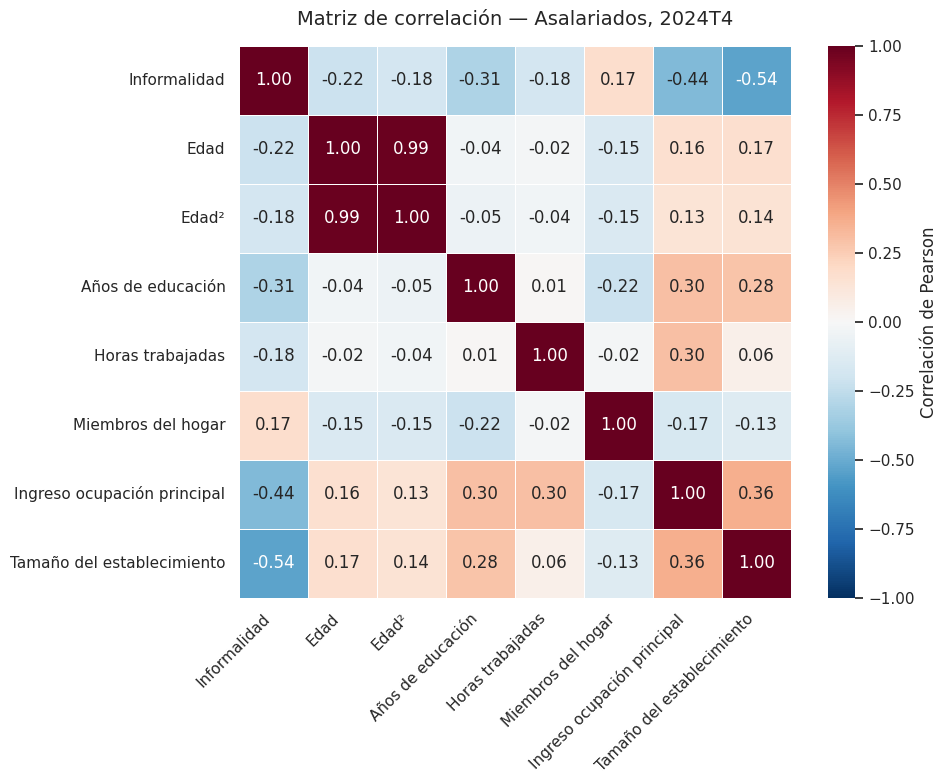

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion_2024_etiquetada,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación de Pearson"}
)

plt.title(
    "Matriz de correlación — Asalariados, 2024T4",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

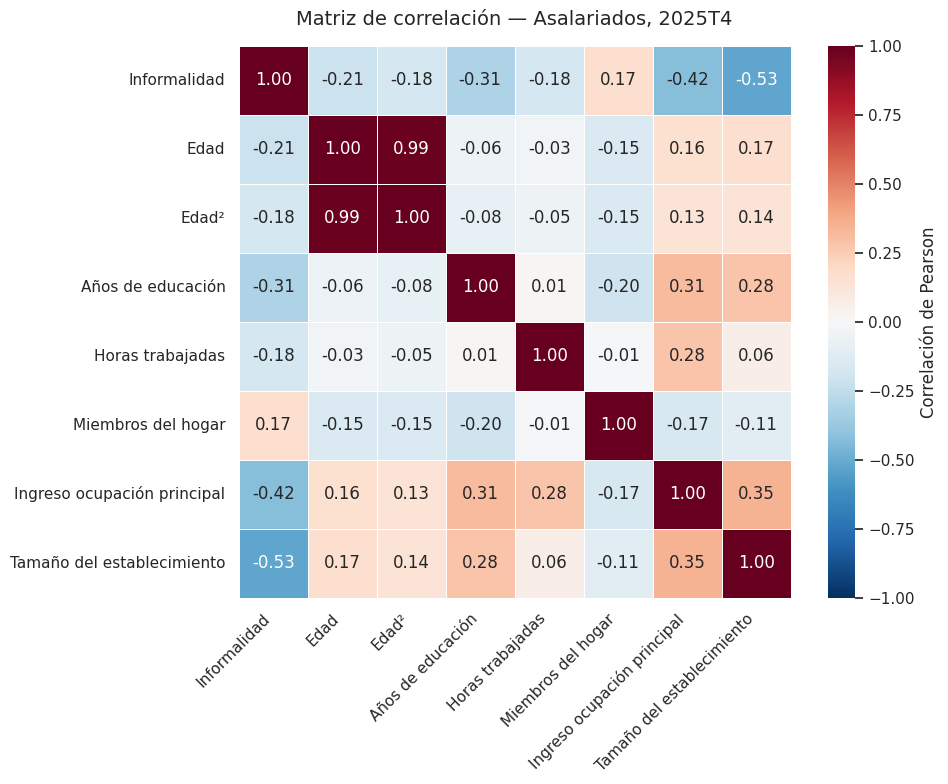

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion_2025_etiquetada,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación de Pearson"}
)

plt.title(
    "Matriz de correlación — Asalariados, 2025T4",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
correlaciones_informalidad = pd.DataFrame({
    "2024T4": correlacion_2024.loc[
        "informal"
    ].drop("informal"),

    "2025T4": correlacion_2025.loc[
        "informal"
    ].drop("informal")
})

correlaciones_informalidad["diferencia_2025_2024"] = (
    correlaciones_informalidad["2025T4"]
    - correlaciones_informalidad["2024T4"]
)

correlaciones_informalidad.index = (
    correlaciones_informalidad.index.map(
        etiquetas_correlacion
    )
)

display(correlaciones_informalidad.round(3))

,2024T4,2025T4,diferencia_2025_2024
Edad,-0.218,-0.214,0.004
Edad²,-0.181,-0.177,0.005
Años de educación,-0.305,-0.312,-0.007
Horas trabajadas,-0.181,-0.178,0.003
Miembros del hogar,0.173,0.170,-0.003
Ingreso ocupación principal,-0.440,-0.423,0.017
Tamaño del establecimiento,-0.536,-0.531,0.005


In [ ]:
diferencia_matrices = (
    correlacion_2025
    - correlacion_2024
).abs()

# Se elimina la diagonal porque siempre es cero
np.fill_diagonal(diferencia_matrices.values, np.nan)

cambio_maximo = diferencia_matrices.stack().idxmax()
valor_cambio_maximo = diferencia_matrices.stack().max()

print(
    "Mayor cambio absoluto entre las matrices:",
    cambio_maximo
)

print(
    "Magnitud del mayor cambio:",
    round(valor_cambio_maximo, 3)
)

Mayor cambio absoluto entre las matrices: ('edad2', 'educ')
Magnitud del mayor cambio: 0.026


In [ ]:
def intensidad_correlacion(valor):
    valor_absoluto = abs(valor)

    if valor_absoluto < 0.20:
        return "baja"
    elif valor_absoluto < 0.50:
        return "moderada"
    else:
        return "alta"


interpretacion_informalidad = (
    correlaciones_informalidad[["2024T4", "2025T4"]]
    .map(intensidad_correlacion)
)

display(interpretacion_informalidad)

,2024T4,2025T4
Edad,moderada,moderada
Edad²,baja,baja
Años de educación,moderada,moderada
Horas trabajadas,baja,baja
Miembros del hogar,baja,baja
Ingreso ocupación principal,moderada,moderada
Tamaño del establecimiento,alta,alta


### Comentario de las matrices de correlación

Las matrices muestran una estructura prácticamente estable entre 2024T4 y
2025T4. La informalidad presenta su asociación negativa más elevada con el
tamaño del establecimiento (-0,536 en 2024 y -0,531 en 2025), seguida por el
ingreso de la ocupación principal (-0,440 y -0,423) y los años de educación
(-0,305 y -0,312). Esto indica que los asalariados de establecimientos de mayor
tamaño, con mayores ingresos y más años de educación tienden a presentar una
menor incidencia de informalidad.

La edad, la edad al cuadrado y las horas trabajadas muestran asociaciones
negativas débiles con la informalidad, mientras que el número de miembros del
hogar presenta una asociación positiva, también débil.

Entre los predictores se destaca la correlación de aproximadamente 0,99 entre
edad y edad al cuadrado, resultado esperable porque una variable es una
transformación determinística de la otra. Fuera de esta relación, predominan
correlaciones bajas o moderadas. El mayor cambio absoluto entre ambas matrices
es de 0,026, por lo que no se identifican modificaciones relevantes en la
estructura de correlaciones entre 2024 y 2025.

# Parte II. Métodos no supervisados

## A. Análisis de Componentes Principales

### 1. Scores del primer y segundo componente

Se aplica Análisis de Componentes Principales a edad, edad al cuadrado, años de
educación, horas trabajadas, número de miembros del hogar, ingreso de la
ocupación principal y tamaño del establecimiento.

Como las variables están expresadas en escalas diferentes, se estandarizan
previamente para que cada una tenga media cero y desvío estándar uno.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# ============================================================
# Parte II.A - PCA
# Preparación de la muestra
# ============================================================

variables_pca = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "P21_analisis",
    "PP04C"
]

columnas_identificacion = [
    "PERIODO",
    "informal",
    "condicion_laboral"
]

base_pca = (
    asalariados[
        columnas_identificacion + variables_pca
    ]
    .copy()
)

# Conversión explícita a formato numérico
for variable in variables_pca:
    base_pca[variable] = pd.to_numeric(
        base_pca[variable],
        errors="coerce"
    )

# Se eliminan infinitos y observaciones incompletas
base_pca = (
    base_pca
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=variables_pca + ["informal"])
    .reset_index(drop=False)
    .rename(columns={"index": "indice_original"})
)

print("Asalariados clasificados:", len(asalariados))
print("Casos completos utilizados en PCA:", len(base_pca))
print(
    "Casos excluidos por datos faltantes:",
    len(asalariados) - len(base_pca)
)

display(
    base_pca.groupby(
        ["PERIODO", "condicion_laboral"],
        observed=True
    )
    .size()
    .rename("cantidad")
    .reset_index()
)

Asalariados clasificados: 29235
Casos completos utilizados en PCA: 18077
Casos excluidos por datos faltantes: 11158


,PERIODO,condicion_laboral,cantidad
0,2024T4,Formal,6526
1,2024T4,Informal,2989
2,2025T4,Formal,5847
3,2025T4,Informal,2715


In [ ]:
# Matriz de variables explicativas
X_pca = base_pca[variables_pca].copy()

# Estandarización
escalador_pca = StandardScaler()

X_pca_estandarizada = escalador_pca.fit_transform(
    X_pca
)

# PCA con los siete componentes posibles
modelo_pca = PCA(n_components=len(variables_pca))

scores_pca = modelo_pca.fit_transform(
    X_pca_estandarizada
)

# Incorporación de los scores a la base
for componente in range(len(variables_pca)):
    base_pca[f"PC{componente + 1}"] = (
        scores_pca[:, componente]
    )

print(
    "Varianza explicada por PC1:",
    round(modelo_pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "Varianza explicada por PC2:",
    round(modelo_pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Varianza acumulada PC1 + PC2:",
    round(
        modelo_pca.explained_variance_ratio_[:2].sum() * 100,
        2
    ),
    "%"
)

Varianza explicada por PC1: 31.74 %
Varianza explicada por PC2: 22.17 %
Varianza acumulada PC1 + PC2: 53.91 %


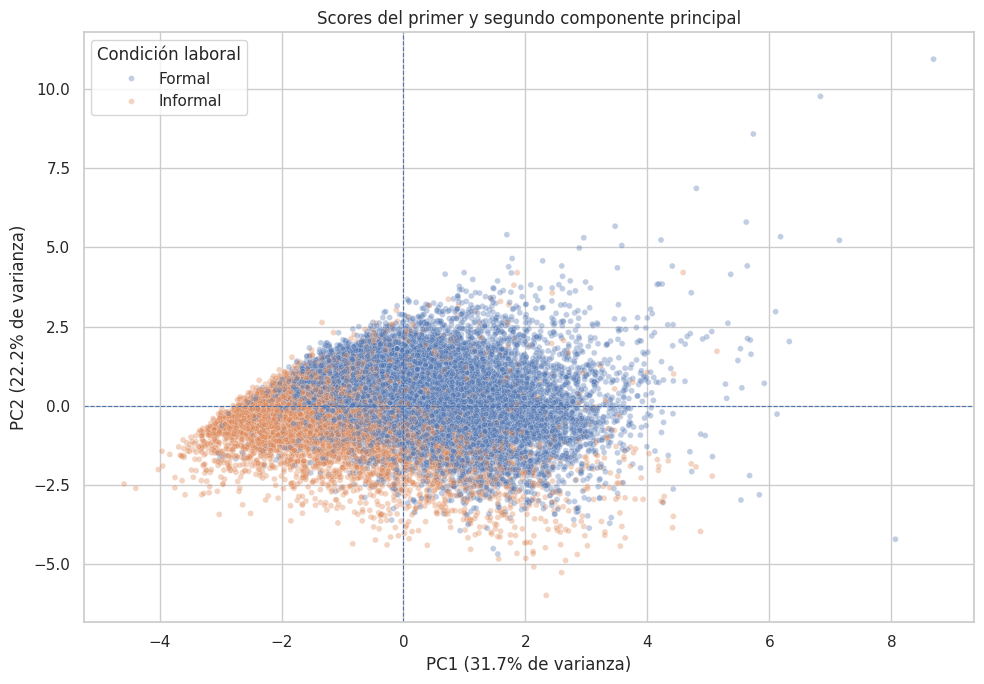

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=base_pca,
    x="PC1",
    y="PC2",
    hue="condicion_laboral",
    alpha=0.35,
    s=18
)

plt.axhline(
    y=0,
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    x=0,
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel(
    f"PC1 ({modelo_pca.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)

plt.ylabel(
    f"PC2 ({modelo_pca.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)

plt.title(
    "Scores del primer y segundo componente principal"
)

plt.legend(
    title="Condición laboral"
)

plt.tight_layout()
plt.show()

In [ ]:
# Distancia respecto del origen en el plano PC1-PC2

base_pca["distancia_scores"] = np.sqrt(
    base_pca["PC1"] ** 2
    + base_pca["PC2"] ** 2
)

# Se consideran observaciones extremas las ubicadas
# por encima del percentil 99,5 de la distancia
umbral_outliers = base_pca["distancia_scores"].quantile(
    0.995
)

base_pca["outlier_pca"] = (
    base_pca["distancia_scores"] > umbral_outliers
)

print("Umbral de distancia:", round(umbral_outliers, 3))
print("Cantidad de outliers:", base_pca["outlier_pca"].sum())

display(
    base_pca.loc[
        base_pca["outlier_pca"],
        [
            "PERIODO",
            "condicion_laboral",
            "PC1",
            "PC2",
            "edad",
            "educ",
            "horastrab",
            "nhogar",
            "P21_analisis",
            "PP04C",
            "distancia_scores"
        ]
    ]
    .sort_values(
        "distancia_scores",
        ascending=False
    )
    .head(20)
)

Umbral de distancia: 4.945
Cantidad de outliers: 91


,PERIODO,condicion_laboral,PC1,PC2,edad,educ,horastrab,nhogar,P21_analisis,PP04C,distancia_scores
7637,2024T4,Formal,8.691662,10.937815,41.0,17.0,30.0,4,19702500.0,9,13.970712
16925,2025T4,Formal,6.837326,9.763843,36.0,17.0,59.0,1,15000000.0,11,11.919801
5891,2024T4,Formal,5.737221,8.576273,31.0,12.0,40.0,3,15762000.0,7,10.318341
10071,2025T4,Formal,8.066429,-4.211052,100.0,12.0,40.0,1,1100000.0,9,9.099463
6727,2024T4,Formal,7.148354,5.221968,61.0,18.0,35.0,1,10508000.0,9,8.852565
6742,2024T4,Formal,4.802474,6.860743,38.0,17.0,45.0,3,10508000.0,12,8.374578
10929,2025T4,Formal,6.182958,5.335299,55.0,18.0,32.0,3,10000000.0,11,8.166663
16668,2025T4,Formal,5.620805,5.796529,49.0,17.0,40.0,1,9400000.0,12,8.074230
13775,2025T4,Formal,5.637651,4.413842,56.0,17.0,40.0,1,8000000.0,11,7.159966
5662,2024T4,Formal,6.102380,2.968606,66.0,18.0,45.0,2,6567500.0,11,6.786138


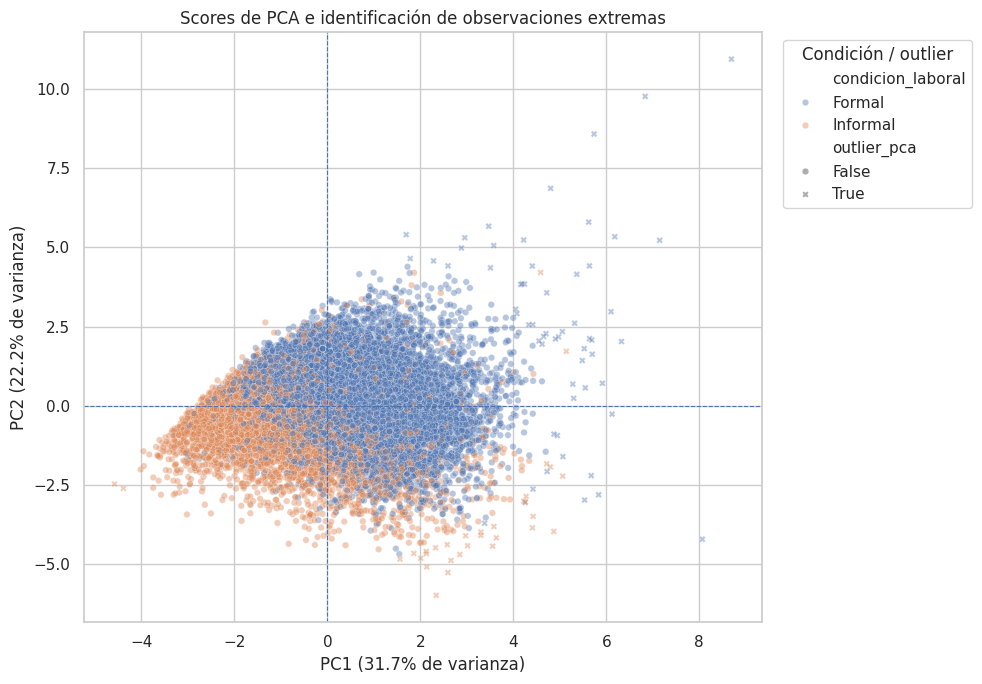

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=base_pca,
    x="PC1",
    y="PC2",
    hue="condicion_laboral",
    style="outlier_pca",
    alpha=0.40,
    s=22
)

plt.axhline(
    y=0,
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    x=0,
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel(
    f"PC1 ({modelo_pca.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)

plt.ylabel(
    f"PC2 ({modelo_pca.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)

plt.title(
    "Scores de PCA e identificación de observaciones extremas"
)

plt.legend(
    title="Condición / outlier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretación de los scores

Los dos primeros componentes principales explican conjuntamente el 53,9% de
la varianza total: PC1 explica el 31,7% y PC2 el 22,2%.

El gráfico muestra una superposición importante entre asalariados formales e
informales, por lo que los dos primeros componentes no permiten separar
con mayor claridad ambas condiciones laborales. Sin embargo, se observa una mayor
concentración de trabajadores informales en valores negativos de PC1, mientras
que los trabajadores formales presentan una distribución más amplia y una
mayor presencia en valores positivos.

El patrón puede interpretarse como una diferenciación gradual y no como la
existencia de dos grupos completamente separados. La condición de informalidad
está relacionada con las características incluidas en el PCA, pero no determina
por sí sola la posición de cada individuo en el espacio de los componentes.

Se identificaron 91 observaciones extremas, definidas como aquellas ubicadas
por encima del percentil 99,5 de la distancia al origen en el plano PC1-PC2.
Estas observaciones se encuentran asociadas principalmente con valores elevados
de ingreso, tamaño del establecimiento, edad u otras combinaciones inusuales.


In [ ]:
# ============================================================
# Parte II.A - Inciso 2
# Loadings del PCA
# ============================================================

etiquetas_pca = {
    "edad": "Edad",
    "edad2": "Edad²",
    "educ": "Años de educación",
    "horastrab": "Horas trabajadas",
    "nhogar": "Miembros del hogar",
    "P21_analisis": "Ingreso principal",
    "PP04C": "Tamaño del establecimiento"
}

# Loadings: correlación aproximada entre las variables
# estandarizadas y los componentes principales
loadings_pca = pd.DataFrame(
    modelo_pca.components_.T
    * np.sqrt(modelo_pca.explained_variance_),
    index=[
        etiquetas_pca[variable]
        for variable in variables_pca
    ],
    columns=[
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ]
)

print("Loadings del primer y segundo componente:")
display(
    loadings_pca[["PC1", "PC2"]]
    .round(3)
    .sort_values("PC1", key=abs, ascending=False)
)

Loadings del primer y segundo componente:


,PC1,PC2
Edad,0.886,-0.446
Edad²,0.870,-0.476
Ingreso principal,0.524,0.535
Tamaño del establecimiento,0.461,0.508
Miembros del hogar,-0.349,-0.316
Años de educación,0.255,0.646
Horas trabajadas,0.078,0.255


In [ ]:
# Posición promedio y mediana de cada grupo en PC1 y PC2

centroides_pca = (
    base_pca.groupby(
        "condicion_laboral",
        observed=True
    )[["PC1", "PC2"]]
    .agg(["mean", "median"])
    .round(3)
)

display(centroides_pca)

PC1           PC2       
                    mean median   mean median
condicion_laboral                            
Formal             0.468  0.392  0.285  0.329
Informal          -1.014 -1.294 -0.617 -0.528

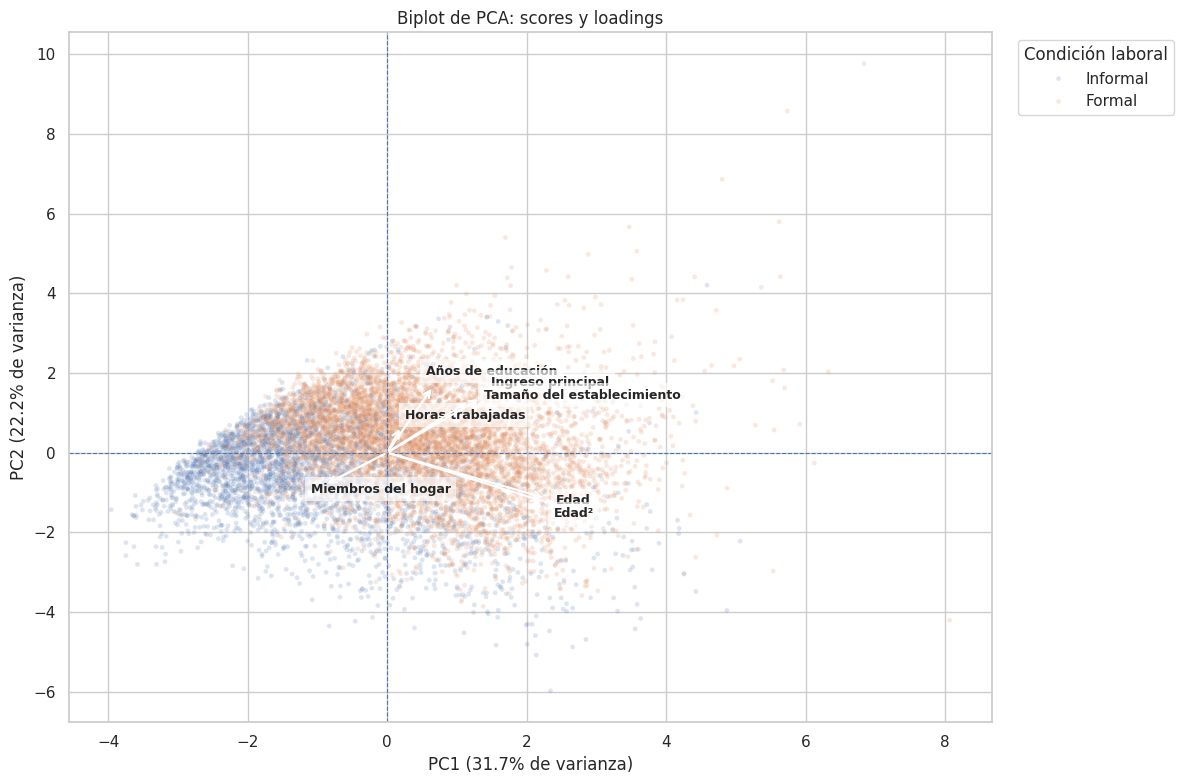

In [ ]:
# Biplot más legible de scores y loadings

fig, ax = plt.subplots(figsize=(12, 8))

# Se utiliza una muestra para mejorar la legibilidad visual.
# El PCA continúa estimado con todos los casos.
muestra_grafico = base_pca.sample(
    n=min(10000, len(base_pca)),
    random_state=123
)

sns.scatterplot(
    data=muestra_grafico,
    x="PC1",
    y="PC2",
    hue="condicion_laboral",
    alpha=0.18,
    s=12,
    ax=ax
)

ax.axhline(0, linestyle="--", linewidth=0.8)
ax.axvline(0, linestyle="--", linewidth=0.8)

# Escala de flechas
escala_x = base_pca["PC1"].abs().quantile(0.98)
escala_y = base_pca["PC2"].abs().quantile(0.98)

factor_flechas = 0.70 * min(
    escala_x / loadings_pca["PC1"].abs().max(),
    escala_y / loadings_pca["PC2"].abs().max()
)

# Desplazamientos manuales para evitar superposición
desplazamientos = {
    "Edad": (0.15, -0.15),
    "Edad²": (0.15, -0.40),
    "Ingreso principal": (0.15, 0.30),
    "Tamaño del establecimiento": (0.20, 0.05),
    "Miembros del hogar": (-0.20, -0.20),
    "Años de educación": (-0.10, 0.30),
    "Horas trabajadas": (0.05, 0.20)
}

for variable in loadings_pca.index:

    x = loadings_pca.loc[variable, "PC1"] * factor_flechas
    y = loadings_pca.loc[variable, "PC2"] * factor_flechas

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(0, 0),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.6
        }
    )

    dx, dy = desplazamientos.get(variable, (0.10, 0.10))

    ax.text(
        x + dx,
        y + dy,
        variable,
        fontsize=9,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "alpha": 0.65,
            "edgecolor": "none"
        }
    )

ax.set_xlabel(
    f"PC1 ({modelo_pca.explained_variance_ratio_[0] * 100:.1f}% de varianza)"
)

ax.set_ylabel(
    f"PC2 ({modelo_pca.explained_variance_ratio_[1] * 100:.1f}% de varianza)"
)

ax.set_title("Biplot de PCA: scores y loadings")

ax.legend(
    title="Condición laboral",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Parte II.A - Inciso 3
# Varianza explicada
# ============================================================

varianza_pca = pd.DataFrame({
    "Componente": [
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ],
    "Varianza explicada (%)": (
        modelo_pca.explained_variance_ratio_
        * 100
    ),
    "Varianza acumulada (%)": (
        np.cumsum(
            modelo_pca.explained_variance_ratio_
        )
        * 100
    )
})

display(varianza_pca.round(2))

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,31.74,31.74
1,PC2,22.17,53.91
2,PC3,15.89,69.80
3,PC4,12.68,82.48
4,PC5,9.32,91.81
5,PC6,8.01,99.81
6,PC7,0.19,100.00


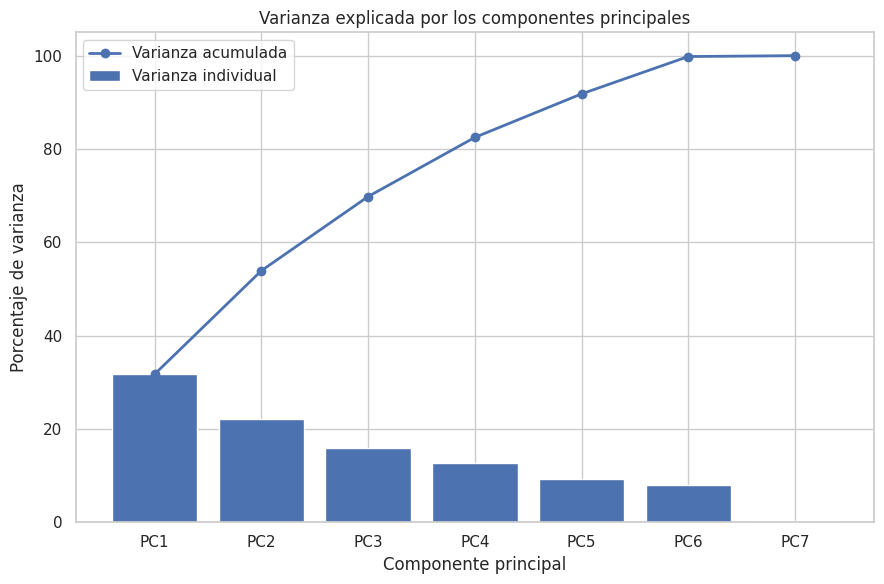

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    varianza_pca["Componente"],
    varianza_pca["Varianza explicada (%)"],
    label="Varianza individual"
)

ax.plot(
    varianza_pca["Componente"],
    varianza_pca["Varianza acumulada (%)"],
    marker="o",
    linewidth=2,
    label="Varianza acumulada"
)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Porcentaje de varianza")
ax.set_title("Varianza explicada por los componentes principales")
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

Los dos primeros componentes explican conjuntamente el 53,9% de la varianza.
Esto indica que el plano PC1-PC2 sintetiza una parte relevante de la información,
pero no reproduce completamente la heterogeneidad de las siete variables.

El resultado es consistente con la matriz de correlaciones. La relación casi
perfecta entre edad y edad al cuadrado permite concentrar buena parte de su
información común en un mismo componente. Sin embargo, las restantes variables
presentan principalmente correlaciones bajas o moderadas, por lo que su
variabilidad se distribuye entre varios componentes y no puede resumirse
completamente en una o dos dimensiones.

### Interpretación de los loadings y la varianza explicada

El primer componente explica el 31,74% de la varianza y está determinado
principalmente por edad, edad al cuadrado, ingreso laboral y tamaño del
establecimiento. Puede interpretarse como una dimensión de ciclo de vida y
consolidación de la inserción laboral: los valores positivos se vinculan con
personas de mayor edad, mayores ingresos y empleos en establecimientos de mayor
tamaño.

El segundo componente explica el 22,17% y presenta sus mayores pesos positivos
en años de educación, ingreso y tamaño del establecimiento, mientras que edad y
edad al cuadrado tienen pesos negativos. Este componente representa una
dimensión vinculada con el capital humano y la calidad del puesto de trabajo.

Los centroides de los asalariados formales son positivos en ambos componentes,
mientras que los de los informales son negativos. Esto muestra una diferenciación
multivariada entre ambos grupos, aunque la superposición observada en el gráfico
indica que el PCA no permite una separación completa.

Los dos primeros componentes explican conjuntamente el 53,91% de la varianza,
mientras que los cuatro primeros alcanzan el 82,48%. La varianza explicada por
PC7 es apenas 0,19%, resultado consistente con la elevada correlación entre edad
y edad al cuadrado.

## B. Análisis de clúster

### 4.a. K-means con dos clústeres

Se aplica el algoritmo k-means sobre las mismas siete variables estandarizadas
utilizadas en el PCA. La variable de informalidad no interviene en la formación
de los grupos y se utiliza posteriormente para evaluar si los clústeres
reproducen la distinción entre asalariados formales e informales.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Se reutiliza X_pca_estandarizada:
# contiene los casos completos y las siete variables estandarizadas

modelo_kmeans_2 = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=123
)

base_pca["cluster_kmeans_2"] = modelo_kmeans_2.fit_predict(
    X_pca_estandarizada
)

display(
    base_pca["cluster_kmeans_2"]
        .value_counts()
        .sort_index()
        .rename("cantidad")
        .to_frame()
)

,cantidad
cluster_kmeans_2,
0,10004
1,8073


In [ ]:
tabla_cluster_informalidad = pd.crosstab(
    base_pca["cluster_kmeans_2"],
    base_pca["condicion_laboral"],
    margins=True
)

display(tabla_cluster_informalidad)

tabla_cluster_porcentajes = pd.crosstab(
    base_pca["cluster_kmeans_2"],
    base_pca["condicion_laboral"],
    normalize="index"
) * 100

display(tabla_cluster_porcentajes.round(1))

condicion_laboral,Formal,Informal,All
cluster_kmeans_2,,,
0,5503,4501,10004
1,6870,1203,8073
All,12373,5704,18077


condicion_laboral,Formal,Informal
cluster_kmeans_2,,
0,55.0,45.0
1,85.1,14.9


In [ ]:
ari_kmeans = adjusted_rand_score(
    base_pca["informal"],
    base_pca["cluster_kmeans_2"]
)

nmi_kmeans = normalized_mutual_info_score(
    base_pca["informal"],
    base_pca["cluster_kmeans_2"]
)

print("Adjusted Rand Index:", round(ari_kmeans, 3))
print("Información mutua normalizada:", round(nmi_kmeans, 3))

Adjusted Rand Index: 0.065
Información mutua normalizada: 0.083


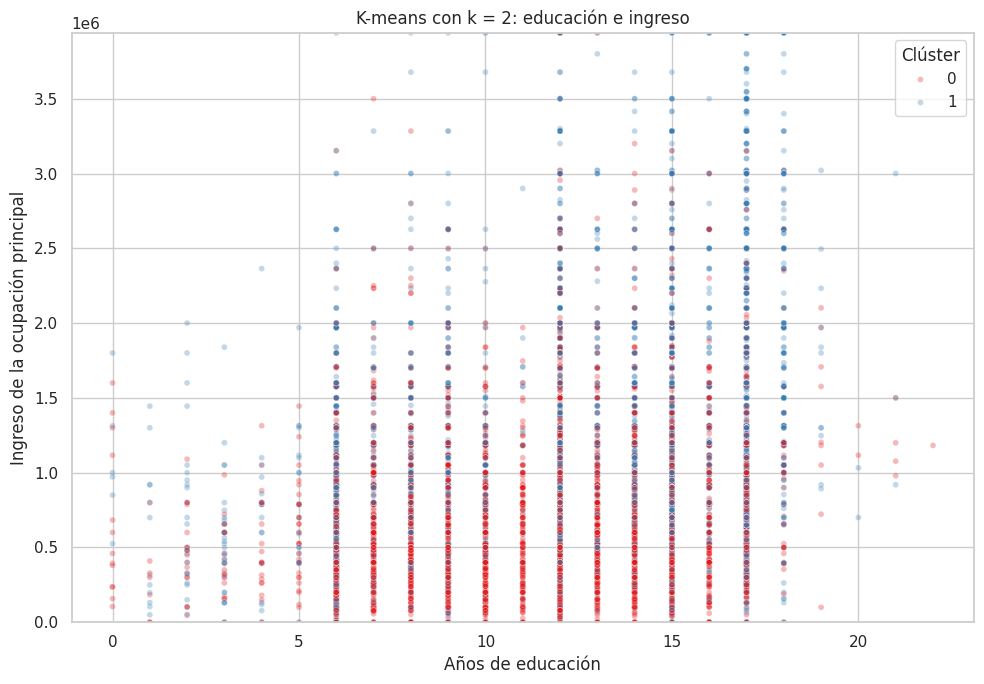

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=base_pca,
    x="educ",
    y="P21_analisis",
    hue="cluster_kmeans_2",
    alpha=0.30,
    s=18,
    palette="Set1"
)

# El percentil 99 mejora la escala sin eliminar observaciones del modelo
limite_ingreso = base_pca["P21_analisis"].quantile(0.99)
plt.ylim(0, limite_ingreso)

plt.xlabel("Años de educación")
plt.ylabel("Ingreso de la ocupación principal")
plt.title("K-means con k = 2: educación e ingreso")
plt.legend(title="Clúster")

plt.tight_layout()
plt.show()

In [ ]:
perfil_clusters = (
    base_pca.groupby("cluster_kmeans_2")[variables_pca]
        .mean()
        .round(2)
)

display(perfil_clusters)

,edad,edad2,educ,horastrab,nhogar,P21_analisis,PP04C
cluster_kmeans_2,,,,,,,
0,31.19,1020.57,12.14,38.36,3.71,761854.28,6.6
1,50.79,2644.96,12.93,39.33,3.13,1299392.18,8.29


#### Interpretación de K-means con k = 2

K-means no logra reproducir correctamente la clasificación entre asalariados
formales e informales. El clúster 1 está compuesto en un 85,1% por trabajadores
formales, pero el clúster 0 presenta una composición mixta, con 55,0% de
formales y 45,0% de informales.

El Adjusted Rand Index es 0,065 y la información mutua normalizada es 0,083.
Estos valores muestran una correspondencia muy baja entre los clústeres y la
condición de informalidad.

Los perfiles promedio indican que el algoritmo separa principalmente dos
configuraciones asociadas al ciclo de vida y a la consolidación laboral. El
clúster 1 reúne personas de mayor edad, mayores ingresos, más educación y
empleos en establecimientos de mayor tamaño. El clúster 0 concentra trabajadores
más jóvenes, con menores ingresos y hogares más numerosos.

En consecuencia, la estructura multivariada de los datos no coincide con una
división binaria estricta entre formalidad e informalidad. La informalidad se
relaciona con estas características, pero no constituye por sí sola dos grupos
naturales perfectamente diferenciados.

### 4.b. Selección del número de clústeres mediante el método del codo

Se estima K-means para valores de k comprendidos entre 1 y 40. Como medida de
disimilitud se utiliza la inercia, definida como la suma de las distancias
cuadráticas de las observaciones respecto del centroide del clúster al que
fueron asignadas.

La inercia disminuye necesariamente cuando aumenta el número de clústeres. El
método del codo busca identificar el punto a partir del cual agregar nuevos
grupos produce reducciones comparativamente pequeñas de la disimilitud.

In [ ]:
# ============================================================
# Parte II.B - Inciso 4.b
# Método del codo para K-means
# ============================================================

rango_k = range(1, 41)
inercias_kmeans = []

for k in rango_k:

    modelo_k = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=123
    )

    modelo_k.fit(X_pca_estandarizada)

    inercias_kmeans.append(
        modelo_k.inertia_
    )

print("Cálculo finalizado.")

Cálculo finalizado.


In [ ]:
tabla_codo_kmeans = pd.DataFrame({
    "k": list(rango_k),
    "inercia": inercias_kmeans
})

tabla_codo_kmeans["reduccion_absoluta"] = (
    tabla_codo_kmeans["inercia"]
    .shift(1)
    - tabla_codo_kmeans["inercia"]
)

tabla_codo_kmeans["reduccion_porcentual"] = (
    tabla_codo_kmeans["reduccion_absoluta"]
    / tabla_codo_kmeans["inercia"].shift(1)
    * 100
)

display(
    tabla_codo_kmeans.round(2)
)

,k,inercia,reduccion_absoluta,reduccion_porcentual
0,1,126539.00,NaN,NaN
1,2,99838.36,26700.64,21.10
2,3,86480.39,13357.97,13.38
3,4,79081.33,7399.06,8.56
4,5,73136.99,5944.35,7.52
5,6,67875.26,5261.73,7.19
6,7,63729.31,4145.95,6.11
7,8,60704.23,3025.08,4.75
8,9,58231.78,2472.45,4.07
9,10,56242.37,1989.41,3.42


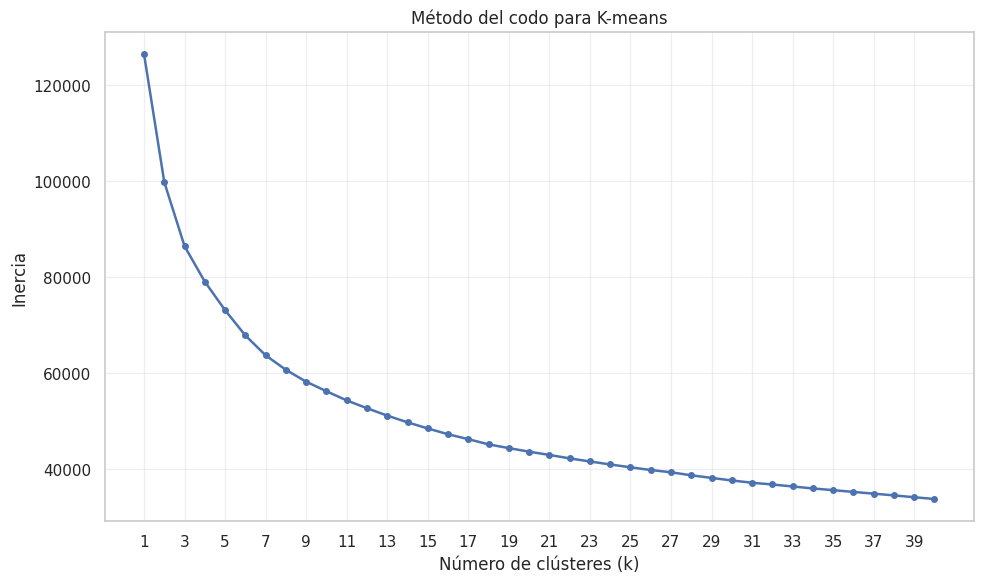

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    tabla_codo_kmeans["k"],
    tabla_codo_kmeans["inercia"],
    marker="o",
    markersize=4,
    linewidth=1.8
)

plt.xticks(range(1, 41, 2))

plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para K-means")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

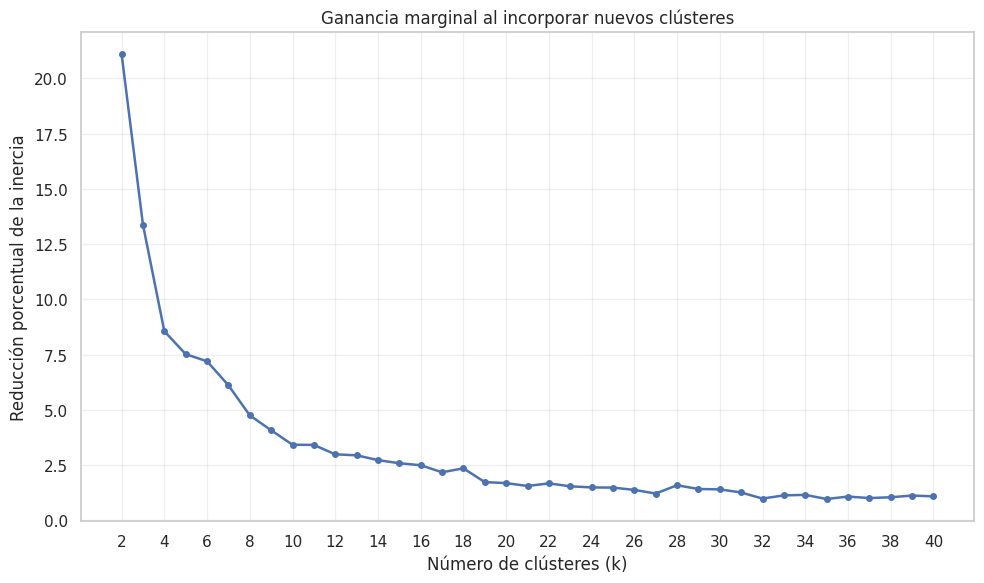

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    tabla_codo_kmeans.loc[
        tabla_codo_kmeans["k"] >= 2,
        "k"
    ],
    tabla_codo_kmeans.loc[
        tabla_codo_kmeans["k"] >= 2,
        "reduccion_porcentual"
    ],
    marker="o",
    markersize=4,
    linewidth=1.8
)

plt.xticks(range(2, 41, 2))

plt.xlabel("Número de clústeres (k)")
plt.ylabel("Reducción porcentual de la inercia")
plt.title("Ganancia marginal al incorporar nuevos clústeres")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretación del método del codo

La inercia disminuye rápidamente para los primeros valores de k. La reducción
es especialmente pronunciada entre uno y cuatro clústeres y continúa siendo
relevante hasta aproximadamente k = 8. A partir de ese punto, la curva comienza
a aplanarse y la incorporación de nuevos grupos genera mejoras marginales cada
vez menores.

El gráfico de reducción porcentual confirma esta lectura: luego de k = 8 la
ganancia asociada a incorporar un clúster adicional cae hacia valores cercanos
o inferiores al 4%.

Por inspección visual, se selecciona k = 8 como número óptimo de clústeres. No
obstante, el codo no es completamente abrupto, por lo que también podría
considerarse razonable un rango comprendido entre ocho y diez grupos.

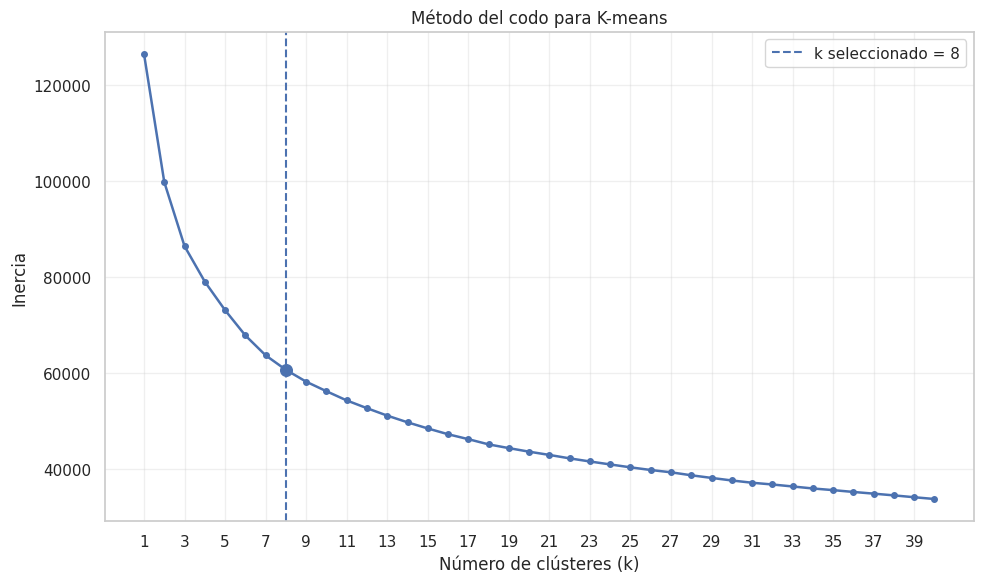

In [ ]:
k_optimo_kmeans = 8

plt.figure(figsize=(10, 6))

plt.plot(
    tabla_codo_kmeans["k"],
    tabla_codo_kmeans["inercia"],
    marker="o",
    markersize=4,
    linewidth=1.8
)

plt.axvline(
    k_optimo_kmeans,
    linestyle="--",
    linewidth=1.5,
    label=f"k seleccionado = {k_optimo_kmeans}"
)

plt.scatter(
    k_optimo_kmeans,
    tabla_codo_kmeans.loc[
        tabla_codo_kmeans["k"].eq(k_optimo_kmeans),
        "inercia"
    ].iloc[0],
    s=70,
    zorder=5
)

plt.xticks(range(1, 41, 2))
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para K-means")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Clustering jerárquico

El clustering jerárquico construye grupos de manera sucesiva. En su versión
aglomerativa, cada observación comienza como un clúster individual y los grupos
más próximos se fusionan progresivamente hasta formar un único conjunto.

El dendrograma representa gráficamente este proceso. Las hojas corresponden a
observaciones o pequeños grupos y la altura de cada unión indica la disimilitud
a la que se fusionan dos clústeres. Saltos verticales grandes sugieren posibles
puntos de corte.

Debido al costo computacional cuadrático de la matriz de distancias, el
dendrograma se construye sobre una muestra aleatoria reproducible de 2.000
asalariados con información completa.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score

In [ ]:
# ============================================================
# Parte II.B - Inciso 5
# Clustering jerárquico
# ============================================================

TAMANIO_MUESTRA_JERARQUICO = min(
    2000,
    len(base_pca)
)

indices_muestra_jerarquico = (
    base_pca.sample(
        n=TAMANIO_MUESTRA_JERARQUICO,
        random_state=123
    )
    .index
    .to_numpy()
)

# Como base_pca y X_pca_estandarizada mantienen el mismo orden,
# los índices pueden aplicarse directamente a la matriz estandarizada.
X_jerarquico = X_pca_estandarizada[
    indices_muestra_jerarquico
]

base_jerarquico = (
    base_pca.loc[indices_muestra_jerarquico]
    .copy()
    .reset_index(drop=True)
)

print(
    "Observaciones utilizadas en clustering jerárquico:",
    len(base_jerarquico)
)

display(
    base_jerarquico["condicion_laboral"]
        .value_counts()
        .rename("cantidad")
        .to_frame()
)

Observaciones utilizadas en clustering jerárquico: 2000


,cantidad
condicion_laboral,
Formal,1338
Informal,662


se usa Ward, porque busca minimizar el aumento de la variabilidad interna al fusionar grupos y es consistente con la distancia euclídea empleada por K-means.

In [ ]:
matriz_enlace = linkage(
    X_jerarquico,
    method="ward",
    metric="euclidean"
)

print(
    "Dimensión de la matriz de enlace:",
    matriz_enlace.shape
)

Dimensión de la matriz de enlace: (1999, 4)


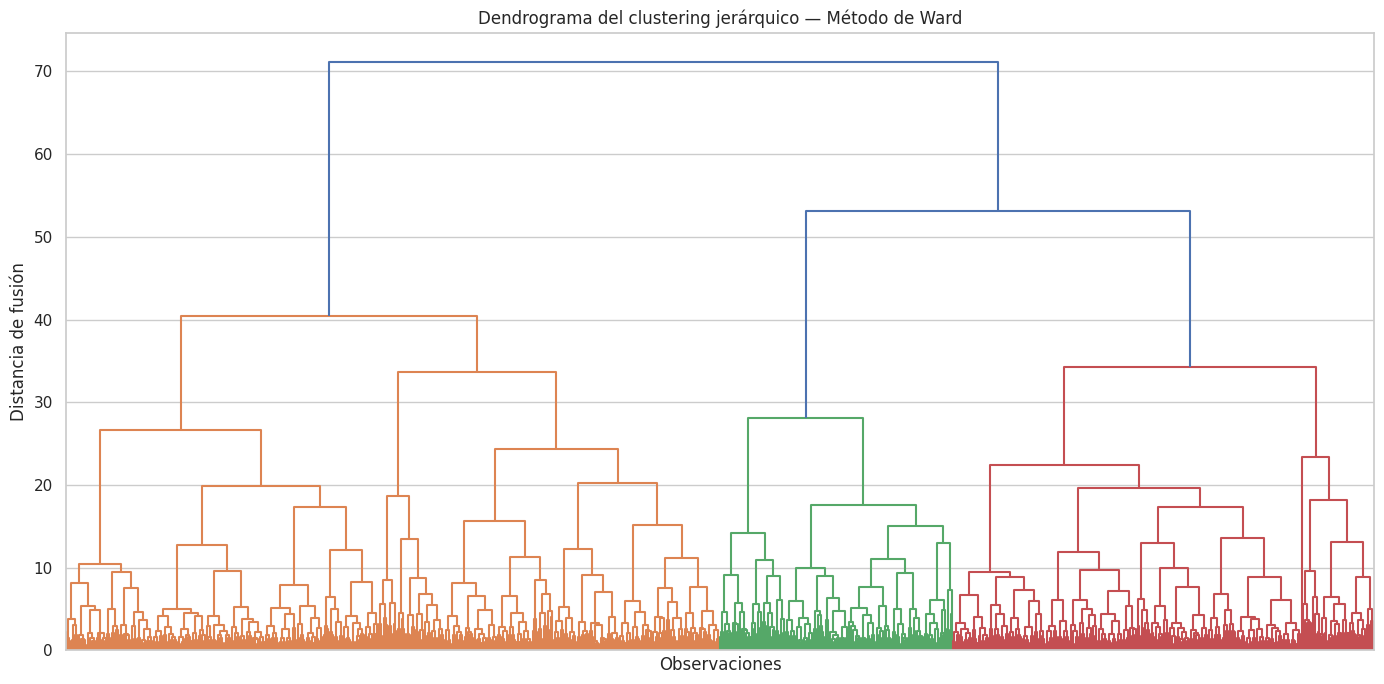

In [ ]:
plt.figure(figsize=(14, 7))

dendrogram(
    matriz_enlace,
    no_labels=True,
    color_threshold=None
)

plt.xlabel("Observaciones")
plt.ylabel("Distancia de fusión")
plt.title(
    "Dendrograma del clustering jerárquico — Método de Ward"
)

plt.tight_layout()
plt.show()

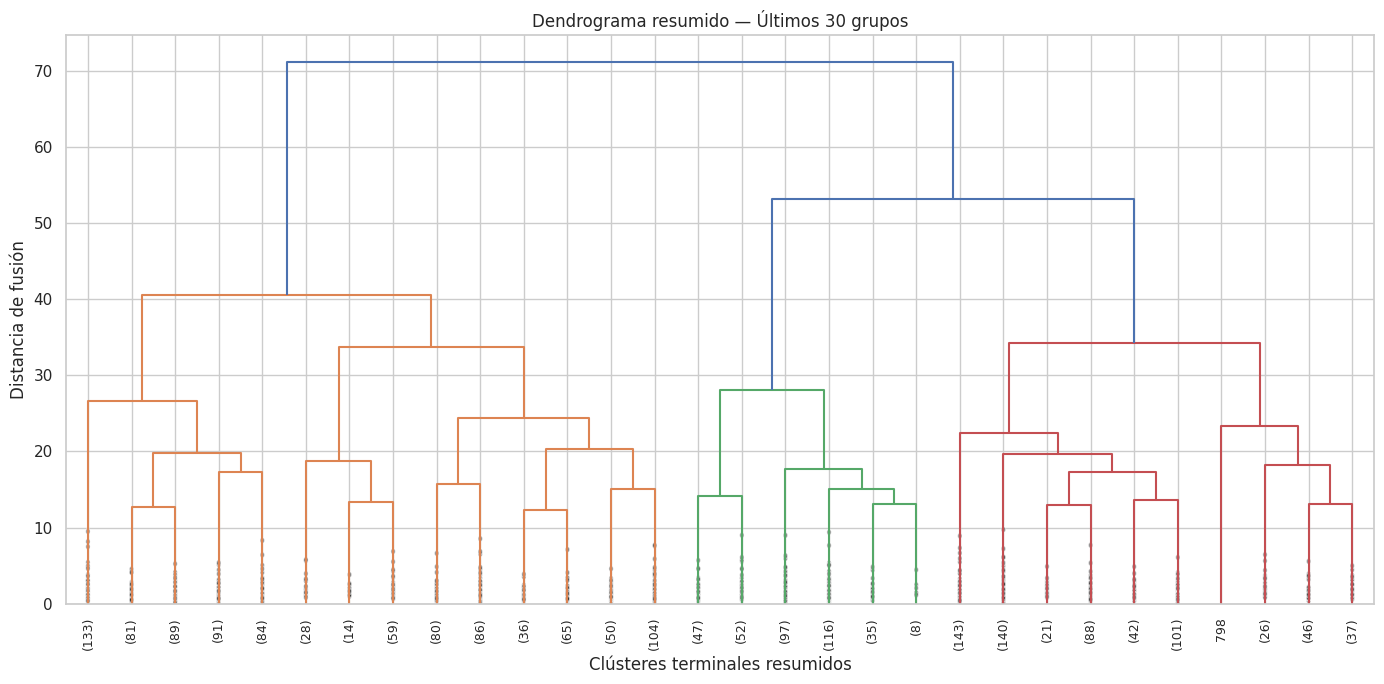

In [ ]:
plt.figure(figsize=(14, 7))

dendrogram(
    matriz_enlace,
    truncate_mode="lastp",
    p=30,
    show_contracted=True,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.xlabel("Clústeres terminales resumidos")
plt.ylabel("Distancia de fusión")
plt.title(
    "Dendrograma resumido — Últimos 30 grupos"
)

plt.tight_layout()
plt.show()

Para comparar con el resultado del método del codo, se particiona el árbol en ocho clústeres. La informalidad no interviene en su construcción.: la estructura jerárquica sugiere aproximadamente tres grandes grupos, no necesariamente ocho.

In [ ]:
NUMERO_CLUSTERS_JERARQUICO = 8

base_jerarquico["cluster_jerarquico"] = fcluster(
    matriz_enlace,
    t=NUMERO_CLUSTERS_JERARQUICO,
    criterion="maxclust"
)

display(
    base_jerarquico["cluster_jerarquico"]
        .value_counts()
        .sort_index()
        .rename("cantidad")
        .to_frame()
)

,cantidad
cluster_jerarquico,
1,133
2,345
3,101
4,421
5,99
6,256
7,535
8,110


In [ ]:
tabla_jerarquico_informalidad = pd.crosstab(
    base_jerarquico["cluster_jerarquico"],
    base_jerarquico["condicion_laboral"]
)

display(tabla_jerarquico_informalidad)

tabla_jerarquico_porcentajes = (
    pd.crosstab(
        base_jerarquico["cluster_jerarquico"],
        base_jerarquico["condicion_laboral"],
        normalize="index"
    )
    * 100
)

display(
    tabla_jerarquico_porcentajes.round(1)
)

condicion_laboral,Formal,Informal
cluster_jerarquico,,
1,18,115
2,250,95
3,29,72
4,181,240
5,52,47
6,212,44
7,487,48
8,109,1


condicion_laboral,Formal,Informal
cluster_jerarquico,,
1,13.5,86.5
2,72.5,27.5
3,28.7,71.3
4,43.0,57.0
5,52.5,47.5
6,82.8,17.2
7,91.0,9.0
8,99.1,0.9


In [ ]:
ari_jerarquico = adjusted_rand_score(
    base_jerarquico["informal"],
    base_jerarquico["cluster_jerarquico"]
)

print(
    "Adjusted Rand Index del clustering jerárquico:",
    round(ari_jerarquico, 3)
)

Adjusted Rand Index del clustering jerárquico: 0.089


In [ ]:
perfil_jerarquico = (
    base_jerarquico
    .groupby("cluster_jerarquico")[variables_pca]
    .mean()
    .round(2)
)

display(perfil_jerarquico)

,edad,edad2,educ,horastrab,nhogar,P21_analisis,PP04C
cluster_jerarquico,,,,,,,
1,24.62,627.73,11.39,21.68,4.05,349133.4,4.19
2,31.28,1030.04,13.65,29.69,3.31,706381.74,8.37
3,34.29,1327.16,10.25,43.5,8.12,594968.03,6.05
4,35.26,1322.89,9.93,44.49,3.48,720340.9,4.73
5,60.7,3723.95,6.03,35.76,3.1,700915.73,5.84
6,56.38,3229.46,13.33,31.65,2.95,946426.29,7.69
7,40.81,1723.36,13.79,43.96,3.06,1254060.24,9.13
8,49.26,2514.43,15.57,43.35,2.96,3022065.32,9.72


In [ ]:
NUMERO_CLUSTERS_JERARQUICO = 3

base_jerarquico["cluster_jerarquico"] = fcluster(
    matriz_enlace,
    t=NUMERO_CLUSTERS_JERARQUICO,
    criterion="maxclust"
)

display(
    base_jerarquico["cluster_jerarquico"]
        .value_counts()
        .sort_index()
        .rename("cantidad")
        .to_frame()
)

,cantidad
cluster_jerarquico,
1,1000
2,355
3,645


In [ ]:
tabla_jerarquico_informalidad = pd.crosstab(
    base_jerarquico["cluster_jerarquico"],
    base_jerarquico["condicion_laboral"],
    margins=True
)

display(tabla_jerarquico_informalidad)

tabla_jerarquico_porcentajes = (
    pd.crosstab(
        base_jerarquico["cluster_jerarquico"],
        base_jerarquico["condicion_laboral"],
        normalize="index"
    )
    * 100
)

display(tabla_jerarquico_porcentajes.round(1))

condicion_laboral,Formal,Informal,All
cluster_jerarquico,,,
1,478,522,1000
2,264,91,355
3,596,49,645
All,1338,662,2000


condicion_laboral,Formal,Informal
cluster_jerarquico,,
1,47.8,52.2
2,74.4,25.6
3,92.4,7.6


In [ ]:
ari_jerarquico = adjusted_rand_score(
    base_jerarquico["informal"],
    base_jerarquico["cluster_jerarquico"]
)

print(
    "Adjusted Rand Index del clustering jerárquico:",
    round(ari_jerarquico, 3)
)

Adjusted Rand Index del clustering jerárquico: 0.075


In [ ]:
perfil_jerarquico = (
    base_jerarquico
    .groupby("cluster_jerarquico")[variables_pca]
    .mean()
    .round(2)
)

display(perfil_jerarquico)

,edad,edad2,educ,horastrab,nhogar,P21_analisis,PP04C
cluster_jerarquico,,,,,,,
1,32.38,1129.83,11.44,36.25,3.97,653491.73,6.05
2,57.58,3367.36,11.3,32.79,2.99,877959.96,7.17
3,42.25,1858.27,14.09,43.86,3.05,1555580.49,9.23


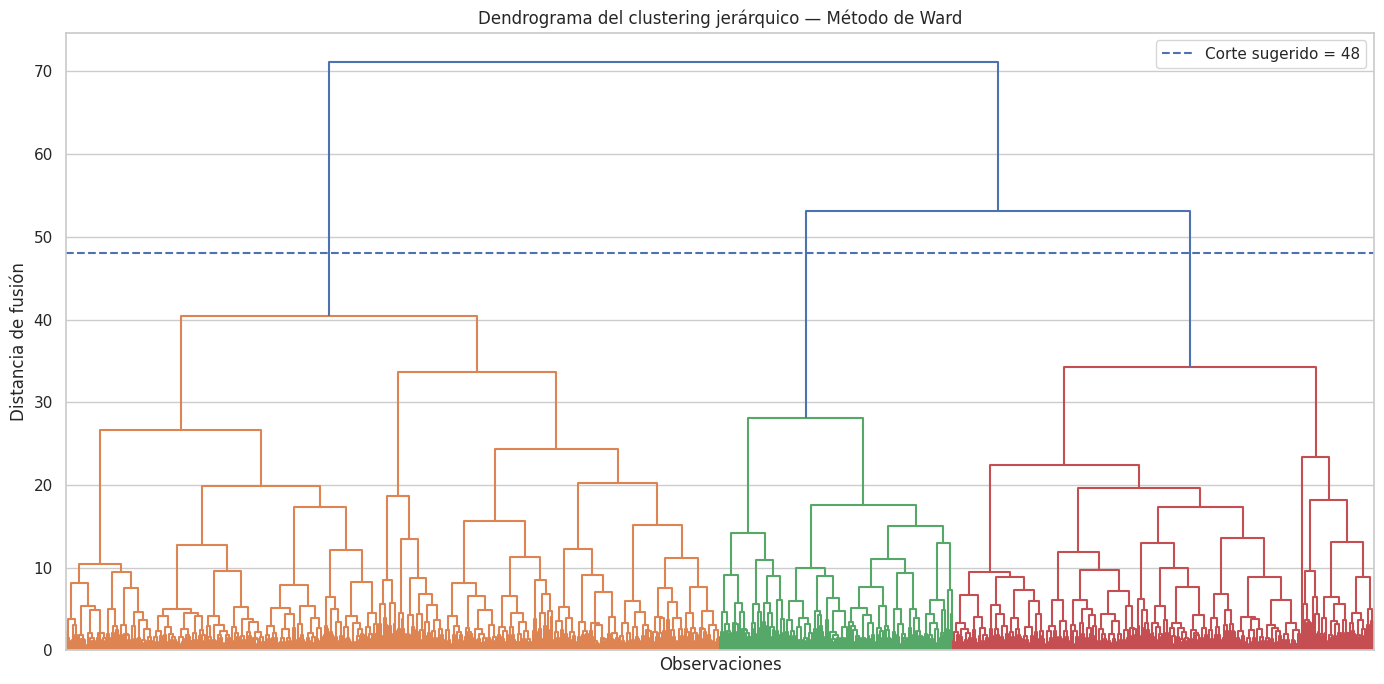

In [ ]:
altura_corte = 48

plt.figure(figsize=(14, 7))

dendrogram(
    matriz_enlace,
    no_labels=True,
    color_threshold=altura_corte
)

plt.axhline(
    y=altura_corte,
    linestyle="--",
    linewidth=1.5,
    label=f"Corte sugerido = {altura_corte}"
)

plt.xlabel("Observaciones")
plt.ylabel("Distancia de fusión")
plt.title(
    "Dendrograma del clustering jerárquico — Método de Ward"
)

plt.legend()
plt.tight_layout()
plt.show()

#### Interpretación del dendrograma

El dendrograma representa el proceso de agrupamiento jerárquico aglomerativo.
Inicialmente, cada observación constituye un grupo independiente. A medida que
aumenta la distancia de fusión, los grupos más similares se combinan hasta
formar un único clúster.

Los principales saltos verticales se observan aproximadamente entre las
distancias 40, 53 y 71. Al realizar un corte cercano a una distancia de 48,
se distinguen tres grandes grupos. Por ese motivo, se adopta una solución de
tres clústeres para describir la estructura jerárquica de la muestra.

La existencia de tres grupos, en lugar de dos, anticipa que la heterogeneidad
de los asalariados no responde exclusivamente a la división entre formalidad
e informalidad. Los grupos también reflejan diferencias en edad, educación,
ingresos, horas trabajadas, tamaño del hogar y características del
establecimiento.

In [ ]:
# ============================================================
# Uso de tres clústeres jerárquicos
# ============================================================

NUMERO_CLUSTERS_JERARQUICO = 3

base_jerarquico["cluster_jerarquico_3"] = fcluster(
    matriz_enlace,
    t=NUMERO_CLUSTERS_JERARQUICO,
    criterion="maxclust"
)

cantidad_clusters_3 = (
    base_jerarquico["cluster_jerarquico_3"]
    .value_counts()
    .sort_index()
    .rename("cantidad")
    .to_frame()
)

display(cantidad_clusters_3)

assert cantidad_clusters_3["cantidad"].sum() == len(base_jerarquico)

,cantidad
cluster_jerarquico_3,
1,1000
2,355
3,645


In [ ]:
tabla_jerarquico_3 = pd.crosstab(
    base_jerarquico["cluster_jerarquico_3"],
    base_jerarquico["condicion_laboral"],
    margins=True
)

display(tabla_jerarquico_3)

porcentajes_jerarquico_3 = (
    pd.crosstab(
        base_jerarquico["cluster_jerarquico_3"],
        base_jerarquico["condicion_laboral"],
        normalize="index"
    )
    * 100
)

display(porcentajes_jerarquico_3.round(1))

condicion_laboral,Formal,Informal,All
cluster_jerarquico_3,,,
1,478,522,1000
2,264,91,355
3,596,49,645
All,1338,662,2000


condicion_laboral,Formal,Informal
cluster_jerarquico_3,,
1,47.8,52.2
2,74.4,25.6
3,92.4,7.6


In [ ]:
ari_jerarquico_3 = adjusted_rand_score(
    base_jerarquico["informal"],
    base_jerarquico["cluster_jerarquico_3"]
)

print(
    "Adjusted Rand Index — solución de tres clústeres:",
    round(ari_jerarquico_3, 3)
)

Adjusted Rand Index — solución de tres clústeres: 0.075


In [ ]:
perfil_jerarquico_3 = (
    base_jerarquico
    .groupby("cluster_jerarquico_3")[variables_pca]
    .agg(["mean", "median"])
    .round(2)
)

display(perfil_jerarquico_3)

edad           edad2           educ        horastrab  \
                       mean median     mean  median   mean median      mean   
cluster_jerarquico_3                                                          
1                     32.38   31.0  1129.83   961.0  11.44   12.0     36.25   
2                     57.58   57.0  3367.36  3249.0   11.3   12.0     32.79   
3                     42.25   42.0  1858.27  1764.0  14.09   15.0     43.86   

                            nhogar        P21_analisis            PP04C         
                     median   mean median         mean     median  mean median  
cluster_jerarquico_3                                                            
1                      40.0   3.97    4.0    653491.73   600000.0  6.05    6.0  
2                      30.0   2.99    3.0    877959.96   800000.0  7.17    8.0  
3                      42.0   3.05    3.0   1555580.49  1313500.0  9.23    9.0

In [ ]:
perfil_jerarquico_3_promedios = (
    base_jerarquico
    .groupby("cluster_jerarquico_3")[variables_pca]
    .mean()
    .rename(columns={
        "edad": "Edad",
        "edad2": "Edad²",
        "educ": "Educación",
        "horastrab": "Horas",
        "nhogar": "Miembros hogar",
        "P21_analisis": "Ingreso",
        "PP04C": "Tamaño establecimiento"
    })
    .round(2)
)

display(perfil_jerarquico_3_promedios)

,Edad,Edad²,Educación,Horas,Miembros hogar,Ingreso,Tamaño establecimiento
cluster_jerarquico_3,,,,,,,
1,32.38,1129.83,11.44,36.25,3.97,653491.73,6.05
2,57.58,3367.36,11.3,32.79,2.99,877959.96,7.17
3,42.25,1858.27,14.09,43.86,3.05,1555580.49,9.23


### 6. Clustering K-modes

K-modes es una extensión de K-means diseñada para variables categóricas. En
lugar de utilizar medias y distancias euclídeas, representa cada grupo mediante
la moda de sus características y mide la disimilitud a partir de la cantidad de
categorías que no coinciden.

Se utilizan las variables binarias construidas para la EPH y las nuevas
variables numéricas del TP2 previamente categorizadas. La informalidad se
excluye de las variables de entrada y se utiliza posteriormente para evaluar
la composición de los clústeres.

In [ ]:
!pip -q install kmodes

In [ ]:
from kmodes.kmodes import KModes

In [ ]:
# ============================================================
# Parte II.B - Inciso 6
# Preparación de variables para K-modes
# ============================================================

base_kmodas = asalariados.copy()

# ------------------------------------------------------------
# Variables binarias
# ------------------------------------------------------------

# Sexo
base_kmodas["mujer"] = (
    base_kmodas["CH04"]
    .map({
        1: "No",
        2: "Sí"
    })
)

# Secundario completo o más
base_kmodas["secundario_completo_o_mas"] = pd.Series(
    pd.NA,
    index=base_kmodas.index,
    dtype="string"
)

base_kmodas.loc[
    base_kmodas["educ"] < 12,
    "secundario_completo_o_mas"
] = "No"

base_kmodas.loc[
    base_kmodas["educ"] >= 12,
    "secundario_completo_o_mas"
] = "Sí"

# Cobertura médica
base_kmodas["con_cobertura_medica"] = (
    base_kmodas["CH08"]
    .map({
        1: "Sí",
        2: "Sí",
        3: "Sí",
        4: "No",
        12: "Sí",
        13: "Sí",
        23: "Sí",
        123: "Sí"
    })
)

# Establecimiento de hasta cinco personas
base_kmodas["empresa_hasta_5"] = pd.Series(
    pd.NA,
    index=base_kmodas.index,
    dtype="string"
)

base_kmodas.loc[
    base_kmodas["PP04C"].between(1, 5),
    "empresa_hasta_5"
] = "Sí"

base_kmodas.loc[
    base_kmodas["PP04C"].between(6, 12),
    "empresa_hasta_5"
] = "No"

In [ ]:
# ------------------------------------------------------------
# Variables numéricas del TP2 categorizadas
# ------------------------------------------------------------

# Edad al cuadrado:
# los puntos de corte equivalen a rangos de edad interpretables
base_kmodas["edad2_cat"] = pd.cut(
    base_kmodas["edad2"],
    bins=[
        -np.inf,
        24**2,
        34**2,
        44**2,
        59**2,
        np.inf
    ],
    labels=[
        "Hasta 24 años",
        "25 a 34 años",
        "35 a 44 años",
        "45 a 59 años",
        "60 años o más"
    ],
    include_lowest=True
)

# Años de educación
base_kmodas["educ_cat"] = pd.cut(
    base_kmodas["educ"],
    bins=[
        -np.inf,
        6,
        9,
        12,
        15,
        17,
        np.inf
    ],
    labels=[
        "Hasta 6 años",
        "7 a 9 años",
        "10 a 12 años",
        "13 a 15 años",
        "16 a 17 años",
        "18 años o más"
    ],
    include_lowest=True
)

# Horas trabajadas
base_kmodas["horastrab_cat"] = pd.cut(
    base_kmodas["horastrab"],
    bins=[
        -np.inf,
        0,
        19,
        34,
        45,
        60,
        np.inf
    ],
    labels=[
        "0 horas",
        "1 a 19 horas",
        "20 a 34 horas",
        "35 a 45 horas",
        "46 a 60 horas",
        "Más de 60 horas"
    ],
    include_lowest=True
)

# Tamaño del hogar
base_kmodas["nhogar_cat"] = pd.cut(
    base_kmodas["nhogar"],
    bins=[
        0,
        1,
        2,
        4,
        np.inf
    ],
    labels=[
        "1 integrante",
        "2 integrantes",
        "3 o 4 integrantes",
        "5 integrantes o más"
    ],
    include_lowest=True
)

In [ ]:
variables_kmodas = [
    "mujer",
    "secundario_completo_o_mas",
    "con_cobertura_medica",
    "empresa_hasta_5",
    "edad2_cat",
    "educ_cat",
    "horastrab_cat",
    "nhogar_cat"
]

control_kmodas = pd.DataFrame({
    "válidos": base_kmodas[variables_kmodas].notna().sum(),
    "faltantes": base_kmodas[variables_kmodas].isna().sum(),
    "porcentaje_faltantes": (
        base_kmodas[variables_kmodas].isna().mean() * 100
    ).round(2)
})

display(control_kmodas)

,válidos,faltantes,porcentaje_faltantes
mujer,29235,0,0.00
secundario_completo_o_mas,28889,346,1.18
con_cobertura_medica,29207,28,0.10
empresa_hasta_5,21190,8045,27.52
edad2_cat,29235,0,0.00
educ_cat,28889,346,1.18
horastrab_cat,29214,21,0.07
nhogar_cat,29235,0,0.00


In [ ]:
base_kmodas_completa = (
    base_kmodas[
        [
            "PERIODO",
            "informal",
            "condicion_laboral"
        ]
        + variables_kmodas
    ]
    .dropna()
    .reset_index(drop=True)
)

# K-modes trabaja con categorías expresadas como texto
X_kmodas = (
    base_kmodas_completa[variables_kmodas]
    .astype(str)
)

print("Asalariados clasificados:", len(asalariados))
print("Casos completos utilizados en K-modes:", len(base_kmodas_completa))
print(
    "Casos excluidos por faltantes:",
    len(asalariados) - len(base_kmodas_completa)
)

display(
    base_kmodas_completa.groupby(
        ["PERIODO", "condicion_laboral"],
        observed=True
    )
    .size()
    .rename("cantidad")
    .reset_index()
)

Asalariados clasificados: 29235
Casos completos utilizados en K-modes: 21013
Casos excluidos por faltantes: 8222


,PERIODO,condicion_laboral,cantidad
0,2024T4,Formal,7614
1,2024T4,Informal,3527
2,2025T4,Formal,6725
3,2025T4,Informal,3147


In [ ]:
modelo_kmodas_2 = KModes(
    n_clusters=2,
    init="Huang",
    n_init=20,
    verbose=0,
    random_state=123
)

base_kmodas_completa["cluster_kmodas_2"] = (
    modelo_kmodas_2.fit_predict(X_kmodas)
)

display(
    base_kmodas_completa["cluster_kmodas_2"]
    .value_counts()
    .sort_index()
    .rename("cantidad")
    .to_frame()
)

print(
    "Costo total de la solución:",
    modelo_kmodas_2.cost_
)

,cantidad
cluster_kmodas_2,
0,14450
1,6563


Costo total de la solución: 64028.0


In [ ]:
tabla_kmodas_informalidad = pd.crosstab(
    base_kmodas_completa["cluster_kmodas_2"],
    base_kmodas_completa["condicion_laboral"],
    margins=True
)

display(tabla_kmodas_informalidad)

porcentajes_kmodas_informalidad = (
    pd.crosstab(
        base_kmodas_completa["cluster_kmodas_2"],
        base_kmodas_completa["condicion_laboral"],
        normalize="index"
    )
    * 100
)

display(
    porcentajes_kmodas_informalidad.round(1)
)

condicion_laboral,Formal,Informal,All
cluster_kmodas_2,,,
0,9408,5042,14450
1,4931,1632,6563
All,14339,6674,21013


condicion_laboral,Formal,Informal
cluster_kmodas_2,,
0,65.1,34.9
1,75.1,24.9


In [ ]:
ari_kmodas = adjusted_rand_score(
    base_kmodas_completa["informal"],
    base_kmodas_completa["cluster_kmodas_2"]
)

nmi_kmodas = normalized_mutual_info_score(
    base_kmodas_completa["informal"],
    base_kmodas_completa["cluster_kmodas_2"]
)

print(
    "Adjusted Rand Index:",
    round(ari_kmodas, 3)
)

print(
    "Información mutua normalizada:",
    round(nmi_kmodas, 3)
)

Adjusted Rand Index: -0.017
Información mutua normalizada: 0.008


In [ ]:
modas_kmodas_2 = pd.DataFrame(
    modelo_kmodas_2.cluster_centroids_,
    columns=variables_kmodas
)

modas_kmodas_2.index.name = "cluster_kmodas_2"

display(modas_kmodas_2)

,mujer,secundario_completo_o_mas,con_cobertura_medica,empresa_hasta_5,edad2_cat,educ_cat,horastrab_cat,nhogar_cat
cluster_kmodas_2,,,,,,,,
0,No,Sí,Sí,No,25 a 34 años,10 a 12 años,35 a 45 horas,3 o 4 integrantes
1,Sí,Sí,Sí,No,45 a 59 años,13 a 15 años,20 a 34 horas,3 o 4 integrantes


In [ ]:
# ============================================================
# Método del codo robusto para K-modes
# ============================================================

rango_k_kmodas = range(1, 16)

resultados_kmodas = []

# Cinco semillas y cinco inicializaciones por semilla:
# 25 soluciones candidatas para cada valor de k.
semillas = range(5)

for k in rango_k_kmodas:

    costos_candidatos = []

    for semilla in semillas:

        modelo_k = KModes(
            n_clusters=k,
            init="Huang",
            n_init=5,
            verbose=0,
            random_state=semilla
        )

        modelo_k.fit(X_kmodas)

        costos_candidatos.append(
            modelo_k.cost_
        )

    resultados_kmodas.append({
        "k": k,
        "costo_minimo": min(costos_candidatos),
        "costo_promedio": np.mean(costos_candidatos),
        "desvio_costos": np.std(costos_candidatos)
    })

    print(
        f"k={k:2d} | "
        f"mínimo={min(costos_candidatos):,.0f} | "
        f"promedio={np.mean(costos_candidatos):,.0f}"
    )

k= 1 | mínimo=75,292 | promedio=75,292
k= 2 | mínimo=64,408 | promedio=65,121
k= 3 | mínimo=58,448 | promedio=59,797
k= 4 | mínimo=54,774 | promedio=55,722
k= 5 | mínimo=51,934 | promedio=53,096
k= 6 | mínimo=49,803 | promedio=50,774
k= 7 | mínimo=48,125 | promedio=49,198
k= 8 | mínimo=46,784 | promedio=48,020
k= 9 | mínimo=45,724 | promedio=46,235
k=10 | mínimo=44,353 | promedio=45,178
k=11 | mínimo=43,434 | promedio=44,280
k=12 | mínimo=42,667 | promedio=43,633
k=13 | mínimo=42,496 | promedio=43,219
k=14 | mínimo=41,368 | promedio=41,935
k=15 | mínimo=40,145 | promedio=41,146


In [109]:
# Tabla definitiva del método del codo robusto

tabla_codo_kmodas_robusta = pd.DataFrame(
    resultados_kmodas
)

tabla_codo_kmodas_robusta["reduccion_absoluta"] = (
    tabla_codo_kmodas_robusta["costo_minimo"].shift(1)
    - tabla_codo_kmodas_robusta["costo_minimo"]
)

tabla_codo_kmodas_robusta["reduccion_porcentual"] = (
    tabla_codo_kmodas_robusta["reduccion_absoluta"]
    / tabla_codo_kmodas_robusta["costo_minimo"].shift(1)
    * 100
)

display(tabla_codo_kmodas_robusta.round(2))

,k,costo_minimo,costo_promedio,desvio_costos,reduccion_absoluta,reduccion_porcentual
0,1,75292.0,75292.0,0.00,NaN,NaN
1,2,64408.0,65121.0,413.62,10884.0,14.46
2,3,58448.0,59797.4,888.67,5960.0,9.25
3,4,54774.0,55722.2,658.30,3674.0,6.29
4,5,51934.0,53096.2,857.51,2840.0,5.18
5,6,49803.0,50774.0,521.27,2131.0,4.10
6,7,48125.0,49197.6,620.05,1678.0,3.37
7,8,46784.0,48019.8,841.84,1341.0,2.79
8,9,45724.0,46234.8,524.33,1060.0,2.27
9,10,44353.0,45178.4,901.79,1371.0,3.00


In [110]:
aumentos_costo = (
    tabla_codo_kmodas_robusta["costo_minimo"]
    .diff()
    .gt(0)
)

if aumentos_costo.any():
    print("Advertencia: todavía hay aumentos del costo.")
    display(
        tabla_codo_kmodas_robusta.loc[
            aumentos_costo,
            ["k", "costo_minimo"]
        ]
    )
else:
    print("Control correcto: el costo mínimo disminuye al aumentar k.")

Control correcto: el costo mínimo disminuye al aumentar k.


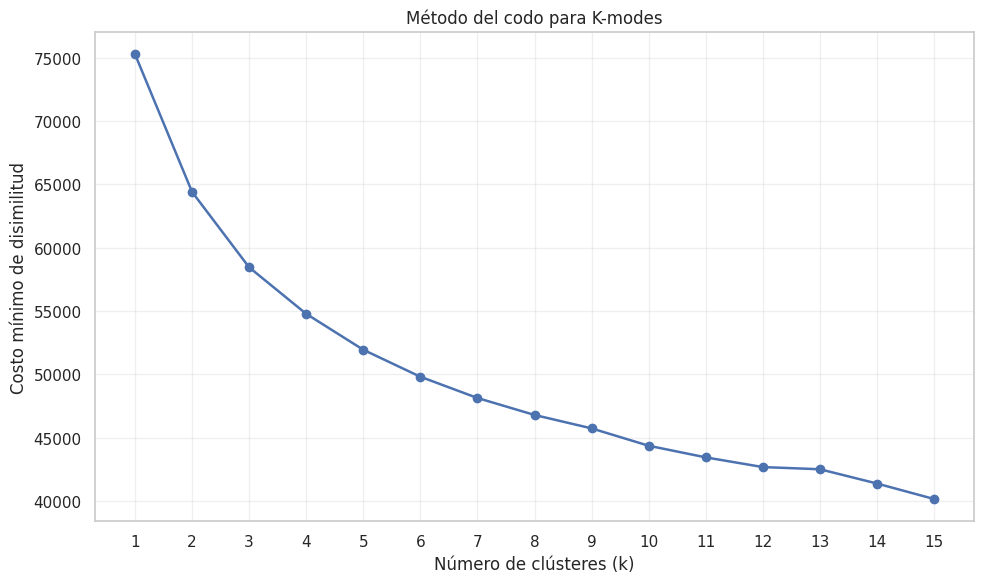

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(
    tabla_codo_kmodas_robusta["k"],
    tabla_codo_kmodas_robusta["costo_minimo"],
    marker="o",
    linewidth=1.8
)

plt.xticks(range(1, 16))
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Costo mínimo de disimilitud")
plt.title("Método del codo para K-modes")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

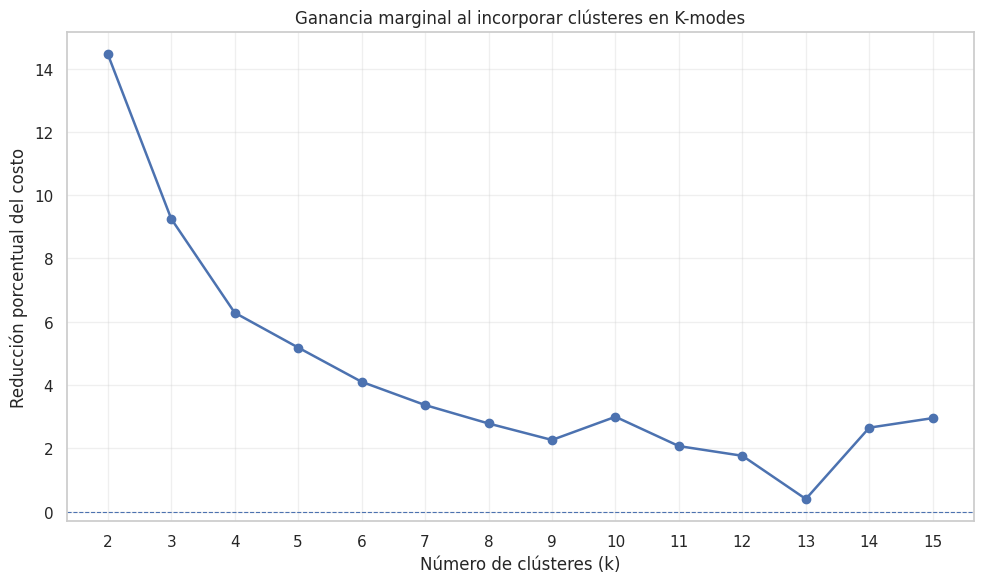

In [112]:
datos_ganancia_kmodas = tabla_codo_kmodas_robusta.loc[
    tabla_codo_kmodas_robusta["k"] >= 2
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    datos_ganancia_kmodas["k"],
    datos_ganancia_kmodas["reduccion_porcentual"],
    marker="o",
    linewidth=1.8
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=0.8
)

plt.xticks(range(2, 16))
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Reducción porcentual del costo")
plt.title("Ganancia marginal al incorporar clústeres en K-modes")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [113]:
# ============================================================
# Solución final de K-modes con k = 5
# ============================================================

K_OPTIMO_KMODES = 5

modelo_kmodas_5 = KModes(
    n_clusters=K_OPTIMO_KMODES,
    init="Huang",
    n_init=50,
    verbose=0,
    random_state=123
)

base_kmodas_completa["cluster_kmodas_5"] = (
    modelo_kmodas_5.fit_predict(X_kmodas)
)

cantidad_kmodas_5 = (
    base_kmodas_completa["cluster_kmodas_5"]
    .value_counts()
    .sort_index()
    .rename("cantidad")
    .to_frame()
)

display(cantidad_kmodas_5)

print(
    "Costo de la solución con cinco clústeres:",
    modelo_kmodas_5.cost_
)

,cantidad
cluster_kmodas_5,
0,9627
1,2460
2,2341
3,4515
4,2070


Costo de la solución con cinco clústeres: 51819.0


In [114]:
tabla_kmodas_5 = pd.crosstab(
    base_kmodas_completa["cluster_kmodas_5"],
    base_kmodas_completa["condicion_laboral"],
    margins=True
)

display(tabla_kmodas_5)

porcentajes_kmodas_5 = (
    pd.crosstab(
        base_kmodas_completa["cluster_kmodas_5"],
        base_kmodas_completa["condicion_laboral"],
        normalize="index"
    )
    * 100
)

display(porcentajes_kmodas_5.round(1))

condicion_laboral,Formal,Informal,All
cluster_kmodas_5,,,
0,7679,1948,9627
1,985,1475,2460
2,252,2089,2341
3,3729,786,4515
4,1694,376,2070
All,14339,6674,21013


condicion_laboral,Formal,Informal
cluster_kmodas_5,,
0,79.8,20.2
1,40.0,60.0
2,10.8,89.2
3,82.6,17.4
4,81.8,18.2


In [115]:
ari_kmodas_5 = adjusted_rand_score(
    base_kmodas_completa["informal"],
    base_kmodas_completa["cluster_kmodas_5"]
)

nmi_kmodas_5 = normalized_mutual_info_score(
    base_kmodas_completa["informal"],
    base_kmodas_completa["cluster_kmodas_5"]
)

print(
    "Adjusted Rand Index:",
    round(ari_kmodas_5, 3)
)

print(
    "Información mutua normalizada:",
    round(nmi_kmodas_5, 3)
)

Adjusted Rand Index: 0.127
Información mutua normalizada: 0.129


In [116]:
modas_kmodas_5 = pd.DataFrame(
    modelo_kmodas_5.cluster_centroids_,
    columns=variables_kmodas
)

modas_kmodas_5.index.name = "cluster_kmodas_5"

display(modas_kmodas_5)

,mujer,secundario_completo_o_mas,con_cobertura_medica,empresa_hasta_5,edad2_cat,educ_cat,horastrab_cat,nhogar_cat
cluster_kmodas_5,,,,,,,,
0,No,Sí,Sí,No,35 a 44 años,10 a 12 años,35 a 45 horas,3 o 4 integrantes
1,Sí,Sí,Sí,Sí,25 a 34 años,10 a 12 años,46 a 60 horas,5 integrantes o más
2,No,No,No,Sí,25 a 34 años,7 a 9 años,35 a 45 horas,3 o 4 integrantes
3,Sí,Sí,Sí,No,45 a 59 años,13 a 15 años,20 a 34 horas,3 o 4 integrantes
4,Sí,Sí,Sí,No,25 a 34 años,16 a 17 años,35 a 45 horas,2 integrantes


In [117]:
resumen_kmodas_5 = pd.DataFrame({
    "cantidad": (
        base_kmodas_completa
        .groupby("cluster_kmodas_5")
        .size()
    ),
    "porcentaje_muestra": (
        base_kmodas_completa
        .groupby("cluster_kmodas_5")
        .size()
        / len(base_kmodas_completa)
        * 100
    ),
    "porcentaje_informal": (
        base_kmodas_completa
        .groupby("cluster_kmodas_5")["informal"]
        .mean()
        * 100
    )
}).round(1)

display(resumen_kmodas_5)

,cantidad,porcentaje_muestra,porcentaje_informal
cluster_kmodas_5,,,
0,9627,45.8,20.2
1,2460,11.7,60.0
2,2341,11.1,89.2
3,4515,21.5,17.4
4,2070,9.9,18.2


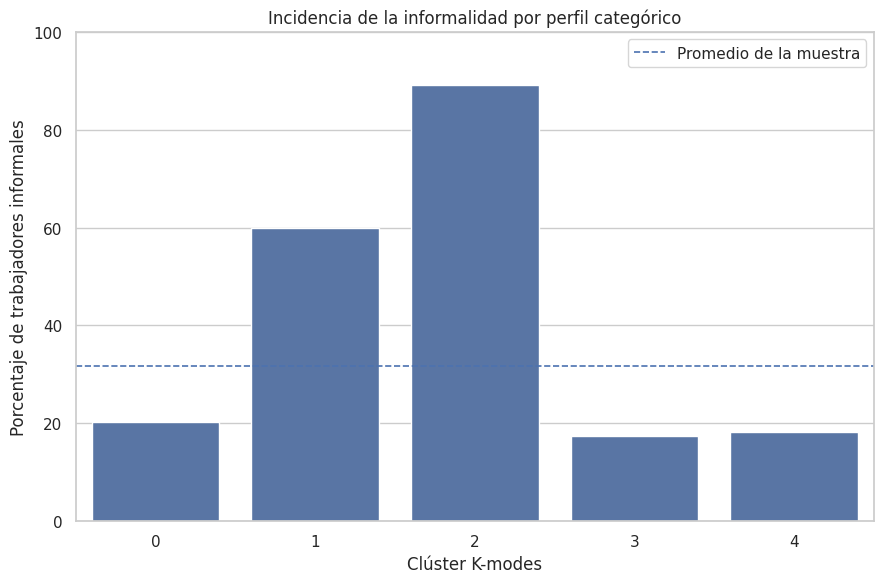

In [118]:
# Porcentaje de informalidad por clúster de K-modes

grafico_informalidad_kmodas = (
    resumen_kmodas_5
    .reset_index()
    .rename(columns={
        "cluster_kmodas_5": "Clúster",
        "porcentaje_informal": "Informalidad"
    })
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=grafico_informalidad_kmodas,
    x="Clúster",
    y="Informalidad"
)

plt.axhline(
    y=base_kmodas_completa["informal"].mean() * 100,
    linestyle="--",
    linewidth=1.2,
    label="Promedio de la muestra"
)

plt.ylabel("Porcentaje de trabajadores informales")
plt.xlabel("Clúster K-modes")
plt.title("Incidencia de la informalidad por perfil categórico")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

El gráfico evidencia una elevada heterogeneidad entre los perfiles identificados
por K-modes. La informalidad promedio de la muestra es de aproximadamente 31,8%.

Los clústeres 1 y 2 superan ampliamente ese valor, con tasas de informalidad del
60,0% y 89,2%, respectivamente. En cambio, los clústeres 0, 3 y 4 presentan tasas
inferiores al 21%.

El resultado muestra que la informalidad no se distribuye uniformemente entre
los asalariados, sino que se concentra en perfiles específicos asociados con
menor educación, falta de cobertura médica, establecimientos pequeños, hogares
numerosos y determinadas configuraciones de edad, sexo y jornada laboral.

#### Resultados de la solución K-modes con cinco clústeres

La solución de cinco clústeres permite identificar perfiles categóricos
claramente diferenciados. Los grupos no representan exclusivamente la
clasificación entre asalariados formales e informales, pero presentan tasas de
informalidad considerablemente diferentes.

El clúster 0 es el más numeroso y representa un perfil masculino, de edad
intermedia, educación media y jornada laboral estándar. El 79,8% de sus
integrantes son formales.

El clúster 1 presenta una mayoría informal del 60%. Su perfil modal corresponde
a mujeres jóvenes, pertenecientes a hogares numerosos y con jornadas laborales
extensas. Esto muestra que una elevada cantidad de horas trabajadas no implica
necesariamente una inserción laboral formal.

El clúster 2 constituye el perfil de mayor vulnerabilidad. Está compuesto
principalmente por varones jóvenes, con bajo nivel educativo, sin cobertura
médica y empleados en establecimientos de hasta cinco personas. La informalidad
alcanza el 89,2% de este grupo.

Los clústeres 3 y 4 presentan tasas de formalidad superiores al 80%. El primero
representa mujeres adultas, con educación superior y jornadas reducidas; el
segundo identifica mujeres jóvenes, con alto nivel educativo, hogares pequeños
y jornadas laborales estándar.

Los clústeres 1 y 2 reúnen solamente el 22,8% de la muestra, pero concentran
aproximadamente el 53,4% de los trabajadores informales. En consecuencia, la
solución con cinco grupos permite identificar perfiles específicos de
vulnerabilidad y consolidación laboral que no serían visibles mediante una
clasificación estrictamente binaria.